# Lead Scoring using Logistic Regression

**Objective:** To build a Lead Scoring model for X Education that predicts which potential lead is likely to convert (purchase a course).

## Project Overview

| Step | Description |
|------|-------------|
| 1. Data Loading | Load the raw CSV data |
| 2. EDA | Exploratory Data Analysis |
| 3. Data Cleaning | Handle missing values |
| 4. Feature Engineering | Transformations and encoding |
| 5. Outlier Removal | 99.7th percentile capping |
| 6. Model Building | Logistic Regression (sklearn + statsmodels) |
| 7. Feature Selection | VIF + coefficient analysis |
| 8. Model Evaluation | Accuracy, Precision, Recall, ROC-AUC |
| 9. Lead Scoring | Assign a 0–100 score to each lead |

---
> **Dataset:** `Lead Scoring.csv`  
> **Target Variable:** `Converted` (1 = converted, 0 = not converted)  
> **Algorithm:** Logistic Regression (`liblinear` solver)

# Lead Scoring Case Study

## Problem Statement-
The company 'X Education' is facing a problem of low conversion of leads to customers, the rate of conversion being around 30%.
To counter this situation, the company wishes to identify the leads most likely to be converted, so that the sales team can focus their attention on them and get as many conversions out of that pool as possible.

## Initial import Statements

In [5]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical computations
import matplotlib.pyplot as plt  # Static plotting
import seaborn as sns        # Statistical data visualization
import warnings
warnings.filterwarnings('ignore')  # Suppress non-essential warnings

# Random color utility – adds color variety to box plots
import random
def randomcolor():
    """Returns a random hex color for each plot."""
    return '#' + ''.join([random.choice('0123456789ABCDEF') for _ in range(6)])

In [6]:
# Load the dataset
# 'Lead Scoring.csv' contains data of X Education's potential leads
leads = pd.read_csv('Lead Scoring.csv')

In [7]:
# Check dataset dimensions (rows, columns)
leads.shape

(9240, 37)

## Data Cleaning

In [9]:
# View data type and non-null count for each column
# This reveals which columns contain missing values
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [10]:
# Count missing (null) values in each column
# This step helps determine which columns to drop or impute
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

Since there are ~9000 data points, we'll keep the missing value threshold 3000. Any columns having more than 3000 missing values shall be dropped.

In [12]:
# Removing columns with more than 3000 missing values

threshold = 3000

for col in leads.columns.tolist():   # .tolist() avoids issues while dropping
    if leads[col].isnull().sum() > threshold:
        leads.drop(columns=col, inplace=True)

# Check missing values after dropping columns
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [13]:
#checking for mode value
leads['Lead Source'].value_counts()

Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Name: count, dtype: int64

#### Data Quality Issue-
There are redundant entries in the column. Eg. (Google,google), (Social Media, Facebook , youtubechannel), (blog, welearnblog_Home)

In [15]:
# Standardize inconsistent values in the 'Lead Source' column
# e.g. 'google' → 'Google', 'Facebook'/'youtubechannel' → 'Social Media'
leads['Lead Source'].replace('google', 'Google', inplace=True)
leads['Lead Source'].replace('youtubechannel', 'Social Media', inplace=True)
leads['Lead Source'].replace('Facebook', 'Social Media', inplace=True)
leads['Lead Source'].replace('welearnblog_Home', 'blog', inplace=True)
leads['Lead Source'].value_counts()

Lead Source
Google               2873
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Social Media           58
bing                    6
Click2call              4
Press_Release           2
Live Chat               2
blog                    2
WeLearn                 1
testone                 1
Pay per Click Ads       1
NC_EDM                  1
Name: count, dtype: int64

In case of categorical vars, we'll impute the mode of the columns into the empty cells.

In [17]:
# Fill missing 'Lead Source' values with the mode ('Google')
# Google is the most common source, making this a safe assumption
leads['Lead Source'] = leads['Lead Source'].fillna('Google')
leads['Lead Source'].value_counts()

Lead Source
Google               2909
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Social Media           58
bing                    6
Click2call              4
Press_Release           2
Live Chat               2
blog                    2
WeLearn                 1
testone                 1
Pay per Click Ads       1
NC_EDM                  1
Name: count, dtype: int64

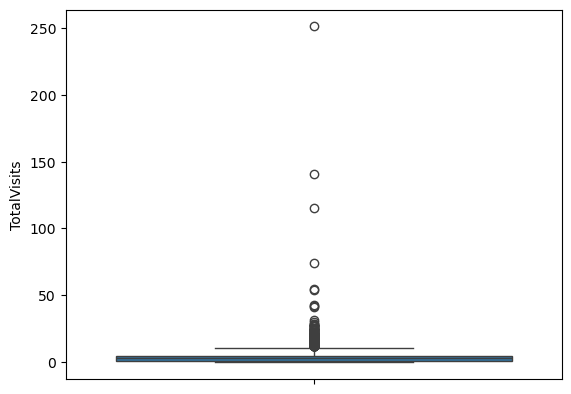

In [18]:
#checking for outliers
sns.boxplot(leads['TotalVisits'])
plt.show()

Since there are outliers, we'll impute missing values by median.

In [20]:
#imputing missing values by median
leads['TotalVisits'].fillna(leads['TotalVisits'].median(), inplace=True)
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

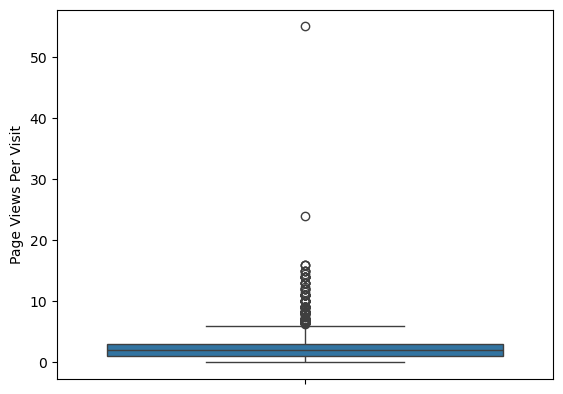

In [21]:
#checking for outliers
sns.boxplot(leads['Page Views Per Visit'])
plt.show()

In [22]:
#imputing by median
leads['Page Views Per Visit'].fillna(leads['Page Views Per Visit'].median(), inplace=True)
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [23]:
#checking for mode value
leads['Last Activity'].value_counts()

Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

In [24]:
# Fill missing values in 'Last Activity' with the most common value
leads['Last Activity'] = leads['Last Activity'].fillna('Email Opened')
leads['Last Activity'].value_counts()

Last Activity
Email Opened                    3540
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

In [25]:
#checking for mode value
leads['Country'].value_counts()

Country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

In [26]:
# 'Country' column: missing → 'India' (most common), Australia → Asia/Pacific
leads['Country'] = leads['Country'].fillna('India')
leads['Country'].replace('Australia', 'Asia/Pacific Region', inplace=True)
leads['Country'].value_counts()

Country
India                   8953
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Asia/Pacific Region       15
Qatar                     10
Bahrain                    7
Hong Kong                  7
Oman                       6
France                     6
unknown                    5
Kuwait                     4
South Africa               4
Canada                     4
Nigeria                    4
Germany                    4
Sweden                     3
Bangladesh                 2
Uganda                     2
Philippines                2
Italy                      2
Netherlands                2
China                      2
Belgium                    2
Ghana                      2
Kenya                      1
Russia                     1
Tanzania                   1
Sri Lanka                  1
Malaysia                   1
Liberia                    1
Switzerland                1
Denmar

In [27]:
#finding next column having null values
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [28]:
#checking for mode value
leads.Specialization.value_counts()

Specialization
Select                               1942
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

"Select" is generall the default option which shows up on the form. Hence we have to treat it like an unknown value.

In [30]:
# 'Select' is a placeholder value indicating no selection was made by the user
# Replace it with 'Unknown' to create a meaningful category
leads.Specialization.replace('Select', 'Unknown', inplace=True)
leads.Specialization.value_counts()

Specialization
Unknown                              1942
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

In [31]:
# Fill remaining missing Specialization values with 'Unknown'
leads.Specialization = leads.Specialization.fillna('Unknown')
leads.Specialization.value_counts()

Specialization
Unknown                              3380
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

In [32]:
#checking for mode value
leads['How did you hear about X Education'].value_counts()

How did you hear about X Education
Select                   5043
Online Search             808
Word Of Mouth             348
Student of SomeSchool     310
Other                     186
Multiple Sources          152
Advertisements             70
Social Media               67
Email                      26
SMS                        23
Name: count, dtype: int64

In [33]:
# 'How did you hear about X Education': 'Select' aur NaN → 'Unknown'
leads['How did you hear about X Education'].replace('Select', 'Unknown', inplace=True)
leads['How did you hear about X Education'] = leads['How did you hear about X Education'].fillna('Unknown')
leads['How did you hear about X Education'].value_counts()

How did you hear about X Education
Unknown                  7250
Online Search             808
Word Of Mouth             348
Student of SomeSchool     310
Other                     186
Multiple Sources          152
Advertisements             70
Social Media               67
Email                      26
SMS                        23
Name: count, dtype: int64

In [34]:
#finding next column with null values
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Specialization                                      0
How did you hear about X Education                  0
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [35]:
#checking for mode value
leads['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              5600
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [36]:
# Fill missing 'Current Occupation' values with 'Unemployed' (most common)
leads['What is your current occupation'] = leads['What is your current occupation'].fillna('Unemployed')
leads['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              8290
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [37]:
#Finding next column with null values
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Specialization                                      0
How did you hear about X Education                  0
What is your current occupation                     0
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [38]:
#checking for mode value
leads['What matters most to you in choosing a course'].value_counts()

What matters most to you in choosing a course
Better Career Prospects      6528
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64

In [39]:
#imputing mode value
leads['What matters most to you in choosing a course']=leads['What matters most to you in choosing a course'].fillna("Better Career Prospects")
leads.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Specialization                                      0
How did you hear about X Education                  0
What is your current occupation                     0
What matters most to you in choosing a course       0
Search                                              0
Magazine                                            0
Newspaper Article           

In [40]:
#checking for mode value
leads['Lead Profile'].value_counts()

Lead Profile
Select                         4146
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [41]:
# 'Lead Profile': 'Select' → 'Unknown', phir NaN → 'Unknown'
leads['Lead Profile'] = leads['Lead Profile'].replace('Select', 'Unknown')
leads['Lead Profile'] = leads['Lead Profile'].fillna('Unknown')
leads['Lead Profile'].value_counts()

Lead Profile
Unknown                        6855
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [42]:
leads['City'].value_counts()

City
Mumbai                         3222
Select                         2249
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

In [43]:
# 'City': Replace both 'Select' placeholder and NaN with 'Unknown'
leads['City'] = leads['City'].replace('Select', 'Unknown')
leads['City'] = leads['City'].fillna('Unknown')

Interestingly, despite having multiple countries, we can see only Indian cities and there is no mention of any international city, or even the word international.

In [45]:
leads[leads['Country']!='India']['City']

14           Unknown
87            Mumbai
103           Mumbai
207          Unknown
243           Mumbai
            ...     
9139          Mumbai
9173         Unknown
9225          Mumbai
9235          Mumbai
9239    Other Cities
Name: City, Length: 287, dtype: object

It makes no sense for mumbai to be a city in an international country. Hence we'll replace it.

In [47]:
leads.loc[leads['Country']!='India','City']="Other International Cities"
leads[leads['Country']!='India']['City']

14      Other International Cities
87      Other International Cities
103     Other International Cities
207     Other International Cities
243     Other International Cities
                   ...            
9139    Other International Cities
9173    Other International Cities
9225    Other International Cities
9235    Other International Cities
9239    Other International Cities
Name: City, Length: 287, dtype: object

While imputing missing data above, we saw quite a lot of categorical columns having highly skewed data i.e. a certain value occupied a disproportionate amount of space in a column compared to others. 

In [49]:
#checking to see the percent of space occupied by the first response compared to others
categorical_columns = leads.select_dtypes(include=['object']).columns
for x in leads[categorical_columns]:
    print(x,": ",round(int(list(leads[x].value_counts())[0])/int(sum(leads[x].value_counts()))*100,2),"%")

Prospect ID :  0.01 %
Lead Origin :  52.88 %
Lead Source :  31.48 %
Do Not Email :  92.06 %
Do Not Call :  99.98 %
Last Activity :  38.31 %
Country :  96.89 %
Specialization :  36.58 %
How did you hear about X Education :  78.46 %
What is your current occupation :  89.72 %
What matters most to you in choosing a course :  99.97 %
Search :  99.85 %
Magazine :  100.0 %
Newspaper Article :  99.98 %
X Education Forums :  99.99 %
Newspaper :  99.99 %
Digital Advertisement :  99.96 %
Through Recommendations :  99.92 %
Receive More Updates About Our Courses :  100.0 %
Update me on Supply Chain Content :  100.0 %
Get updates on DM Content :  100.0 %
Lead Profile :  74.19 %
City :  39.06 %
I agree to pay the amount through cheque :  100.0 %
A free copy of Mastering The Interview :  68.74 %
Last Notable Activity :  36.87 %


They can be safely removed as they won't contribute much.
Choosing 80% as threshold(if any value appears more than 80% of the time in a column, it shall be dropped)

In [51]:
for x in leads[categorical_columns]:
    if (int(list(leads[x].value_counts())[0])/int(sum(leads[x].value_counts())))*100>80:
        del leads[x]

In [52]:
#verifying
for x in leads.columns:
    print(x,": ",round(int(list(leads[x].value_counts())[0])/int(sum(leads[x].value_counts()))*100,2),"%")

Prospect ID :  0.01 %
Lead Number :  0.01 %
Lead Origin :  52.88 %
Lead Source :  31.48 %
Converted :  61.46 %
TotalVisits :  23.69 %
Total Time Spent on Website :  23.73 %
Page Views Per Visit :  23.69 %
Last Activity :  38.31 %
Specialization :  36.58 %
How did you hear about X Education :  78.46 %
Lead Profile :  74.19 %
City :  39.06 %
A free copy of Mastering The Interview :  68.74 %
Last Notable Activity :  36.87 %


In [53]:
#rechecking column information
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Prospect ID                             9240 non-null   object 
 1   Lead Number                             9240 non-null   int64  
 2   Lead Origin                             9240 non-null   object 
 3   Lead Source                             9240 non-null   object 
 4   Converted                               9240 non-null   int64  
 5   TotalVisits                             9240 non-null   float64
 6   Total Time Spent on Website             9240 non-null   int64  
 7   Page Views Per Visit                    9240 non-null   float64
 8   Last Activity                           9240 non-null   object 
 9   Specialization                          9240 non-null   object 
 10  How did you hear about X Education      9240 non-null   obje

## EDA, Visualizations

In [55]:
import random
from scipy.stats import norm, skew

In [56]:
#defining function for selecting a random color for plots
def randomcolor():
    r = random.random()
    b = random.random()
    g = random.random()
    rgb = [r,g,b]
    return rgb

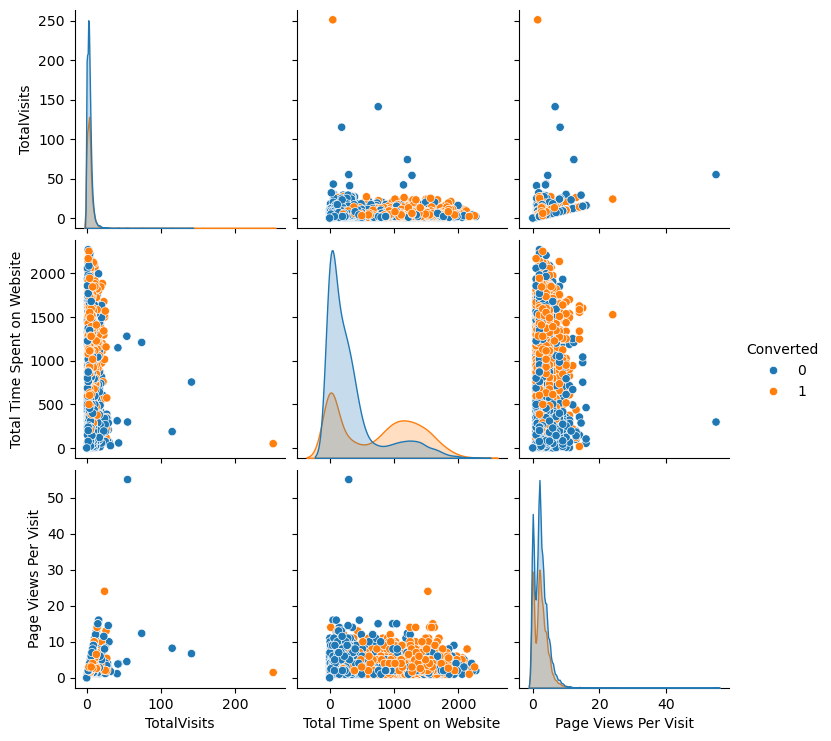

In [57]:
lead2 = leads.drop('Lead Number',axis=1,inplace=False)
sns.pairplot(lead2,diag_kind='kde',hue='Converted')
plt.show()

#### Observations:
1. Converted leads tend to visit less often but spend more time per visit (middle left)
2. Converted leads tend to visit less often but generally view more pages per visit (bottom left)

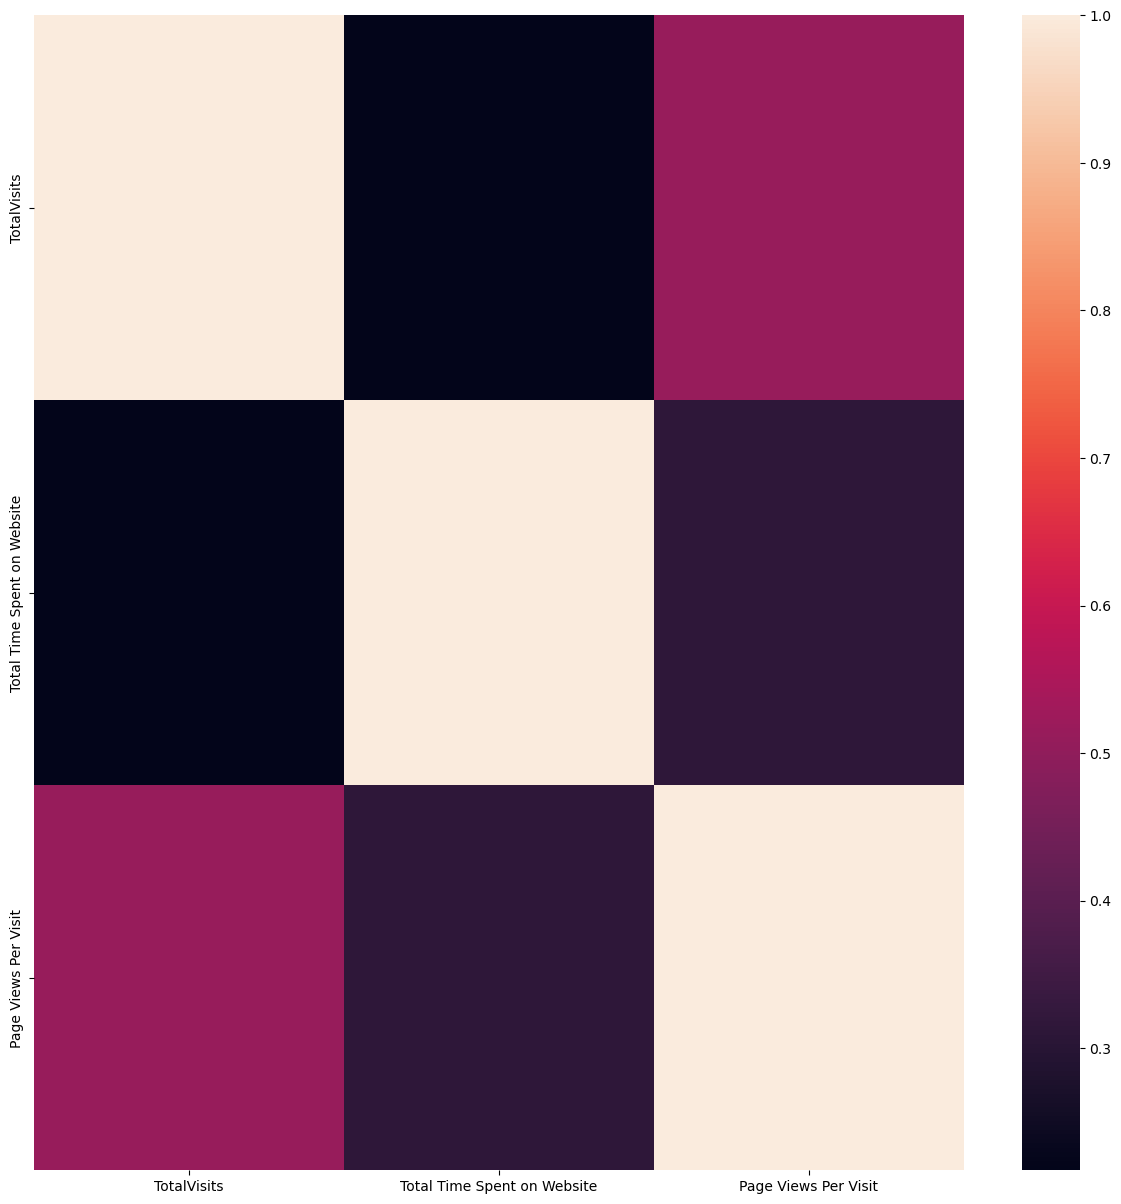

In [59]:
plt.figure(figsize = (15,15))
sns.heatmap(leads[['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']].corr())
plt.show()

#### Observation- 
There doesn't seem to be much correlation between the numerical variables.

### Univariate analysis of numerical variables

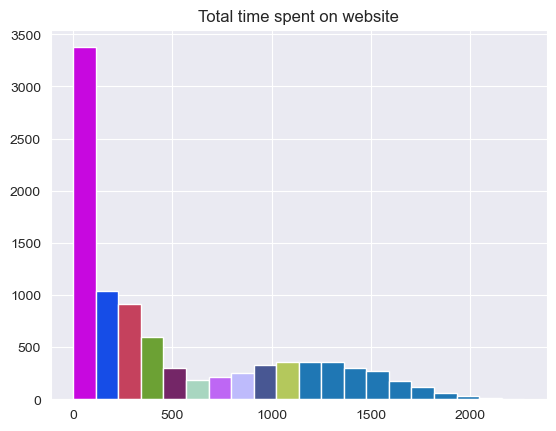

In [62]:
sns.set_style("darkgrid")
fig, ax = plt.subplots()
N,bins,patches = ax.hist(leads['Total Time Spent on Website'],bins=20)
for i in range(10):
    patches[i].set_facecolor(randomcolor())
plt.title("Total time spent on website")
plt.show()

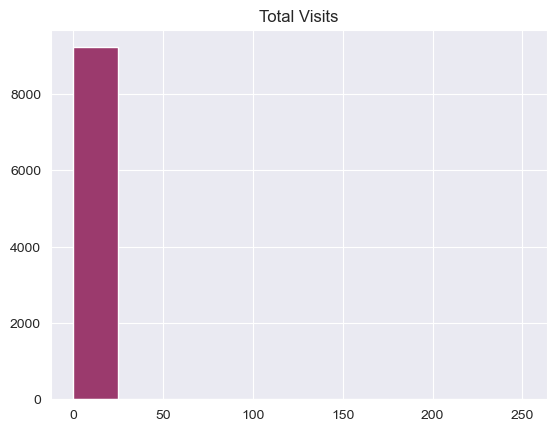

In [63]:
sns.set_style("darkgrid")
fig, ax = plt.subplots()
N,bins,patches = ax.hist(leads['TotalVisits'],bins=10)
for i in range(3):
    patches[i].set_facecolor(randomcolor())
plt.title("Total Visits")
plt.show()

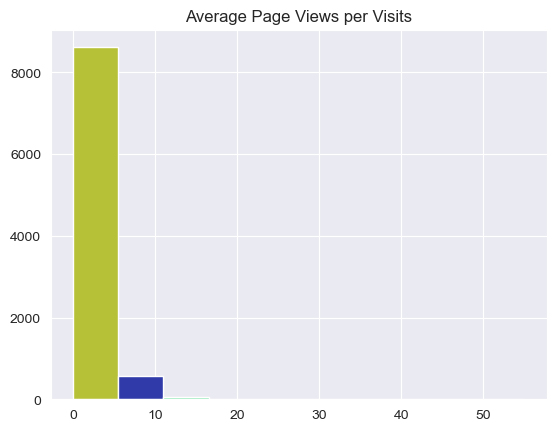

In [64]:
sns.set_style("darkgrid")
fig, ax = plt.subplots()
N,bins,patches = ax.hist(leads['Page Views Per Visit'],bins=10)
for i in range(3):
    patches[i].set_facecolor(randomcolor())
plt.title("Average Page Views per Visits")
plt.show()

The numerical data seems to be highly skewed. Let's look a little deeper.

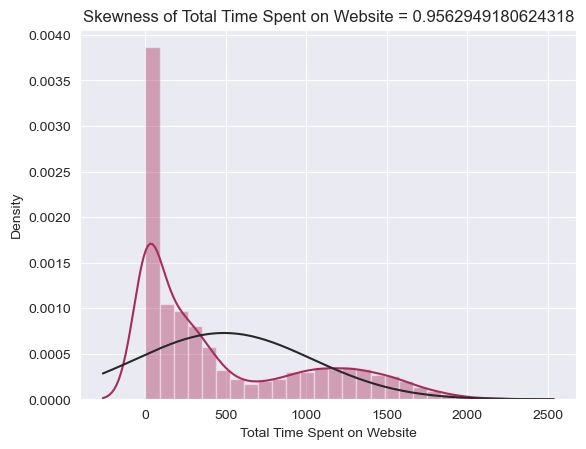

In [66]:
#checking skewness of numerical data
skewness = str(skew(leads['Total Time Spent on Website']))
sns.distplot(leads['Total Time Spent on Website'],fit = norm,color = randomcolor())
plt.title("Skewness of " + 'Total Time Spent on Website'+ ' = '+ skewness)
plt.show()

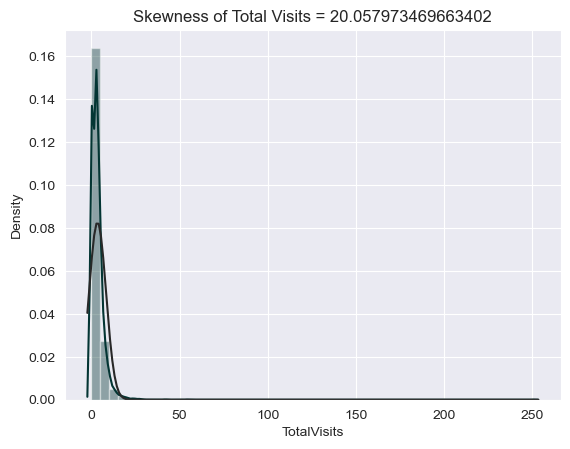

In [67]:
skewness = str(skew(leads['TotalVisits']))
sns.distplot(leads['TotalVisits'],fit = norm,color = randomcolor())
plt.title("Skewness of " + 'Total Visits'+ ' = '+ skewness)
plt.show()

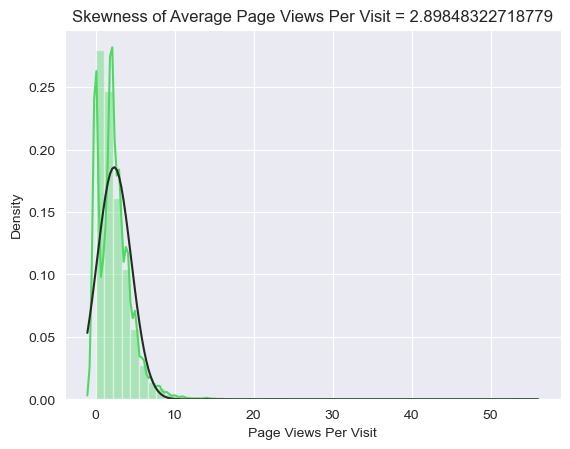

In [68]:
skewness = str(skew(leads['Page Views Per Visit']))
sns.distplot(leads['Page Views Per Visit'],fit = norm,color = randomcolor())
plt.title("Skewness of " + 'Average Page Views Per Visit'+ ' = '+ skewness)
plt.show()

As we can see, the numerical variables are highly skewed. Correcting skewness using square root transformation.

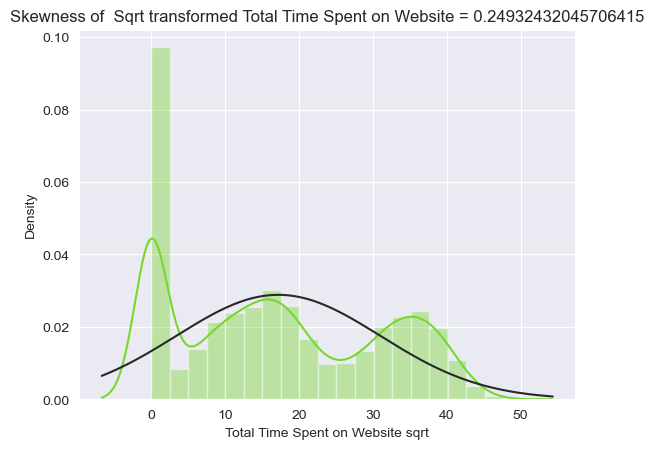

In [70]:
#using np.sqrt for square root transformation.
leads['Total Time Spent on Website sqrt'] = np.sqrt(leads['Total Time Spent on Website'])
skewness = str(skew(leads['Total Time Spent on Website sqrt']))
sns.distplot(leads['Total Time Spent on Website sqrt'],fit = norm,color = randomcolor())
plt.title("Skewness of " + ' Sqrt transformed Total Time Spent on Website'+ ' = '+ skewness)
plt.show()

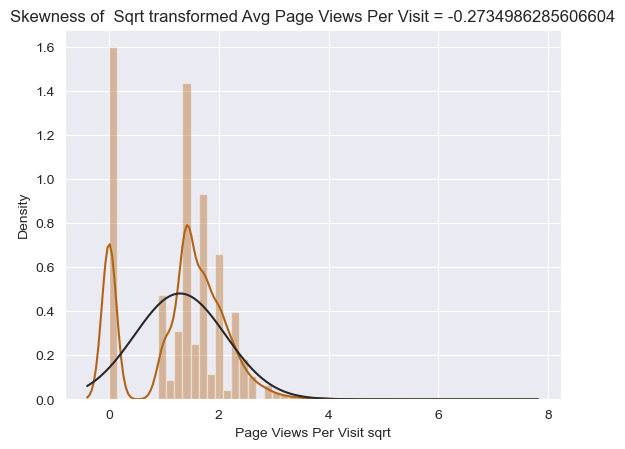

In [71]:
leads['Page Views Per Visit sqrt'] = np.sqrt(leads['Page Views Per Visit'])
skewness = str(skew(leads['Page Views Per Visit sqrt']))
sns.distplot(leads['Page Views Per Visit sqrt'],fit = norm,color = randomcolor())
plt.title("Skewness of " + ' Sqrt transformed Avg Page Views Per Visit'+ ' = '+ skewness)
plt.show()

In [72]:
# Apply square-root transformation to skewed numerical columns
# This brings the distribution closer to normal, which is better suited for logistic regression
leads['TotalVisits_sqrt'] = np.sqrt(leads['TotalVisits'])
leads['Total Time Spent on Website sqrt'] = np.sqrt(leads['Total Time Spent on Website'])
leads['Page Views Per Visit sqrt'] = np.sqrt(leads['Page Views Per Visit'])

As you can see, skewness in the numerical columns has significantly decreased.

In [74]:
#removing the original numerical variables, since we have their transformed versions.
del leads['Page Views Per Visit']
del leads['Total Time Spent on Website']
del leads['TotalVisits']

### Categorical variable analysis

In [76]:
#selecting categorical columns from the dataset.
leads.select_dtypes(include=['object'])

,Prospect ID,Lead Origin,Lead Source,Last Activity,Specialization,How did you hear about X Education,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,API,Olark Chat,Page Visited on Website,Unknown,Unknown,Unknown,Unknown,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,API,Organic Search,Email Opened,Unknown,Unknown,Unknown,Unknown,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,Landing Page Submission,Direct Traffic,Email Opened,Business Administration,Unknown,Potential Lead,Mumbai,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,Landing Page Submission,Direct Traffic,Unreachable,Media and Advertising,Word Of Mouth,Unknown,Mumbai,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,Landing Page Submission,Google,Converted to Lead,Unknown,Other,Unknown,Mumbai,No,Modified
...,...,...,...,...,...,...,...,...,...,...
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,Landing Page Submission,Direct Traffic,Email Marked Spam,IT Projects Management,Unknown,Potential Lead,Other International Cities,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,Landing Page Submission,Direct Traffic,SMS Sent,Media and Advertising,Unknown,Potential Lead,Mumbai,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,Landing Page Submission,Direct Traffic,SMS Sent,Business Administration,Unknown,Potential Lead,Mumbai,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,Landing Page Submission,Google,SMS Sent,Human Resource Management,Online Search,Unknown,Other Metro Cities,No,SMS Sent


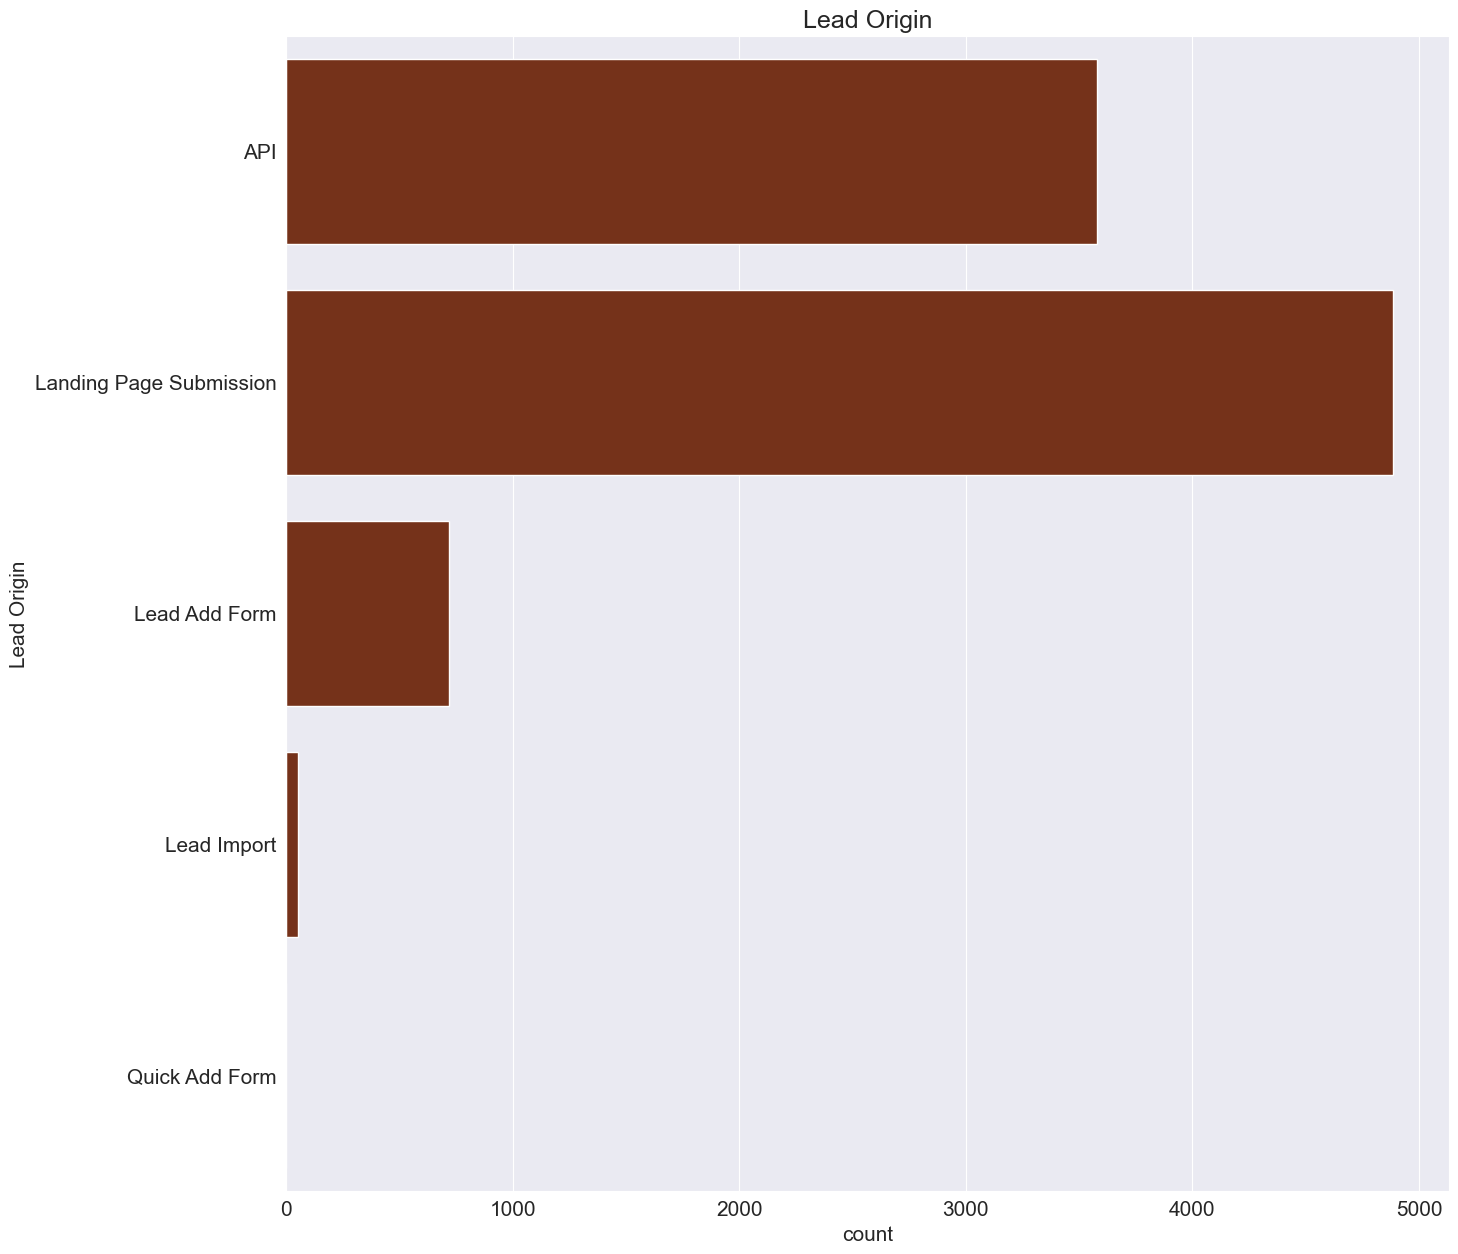

In [77]:
#bar chart counting number of leads by origin.
plt.figure(figsize=(15,15))
plt.rcParams.update({'font.size': 15})
sns.countplot(leads['Lead Origin'],color = randomcolor()).set_title('Lead Origin')
plt.show()

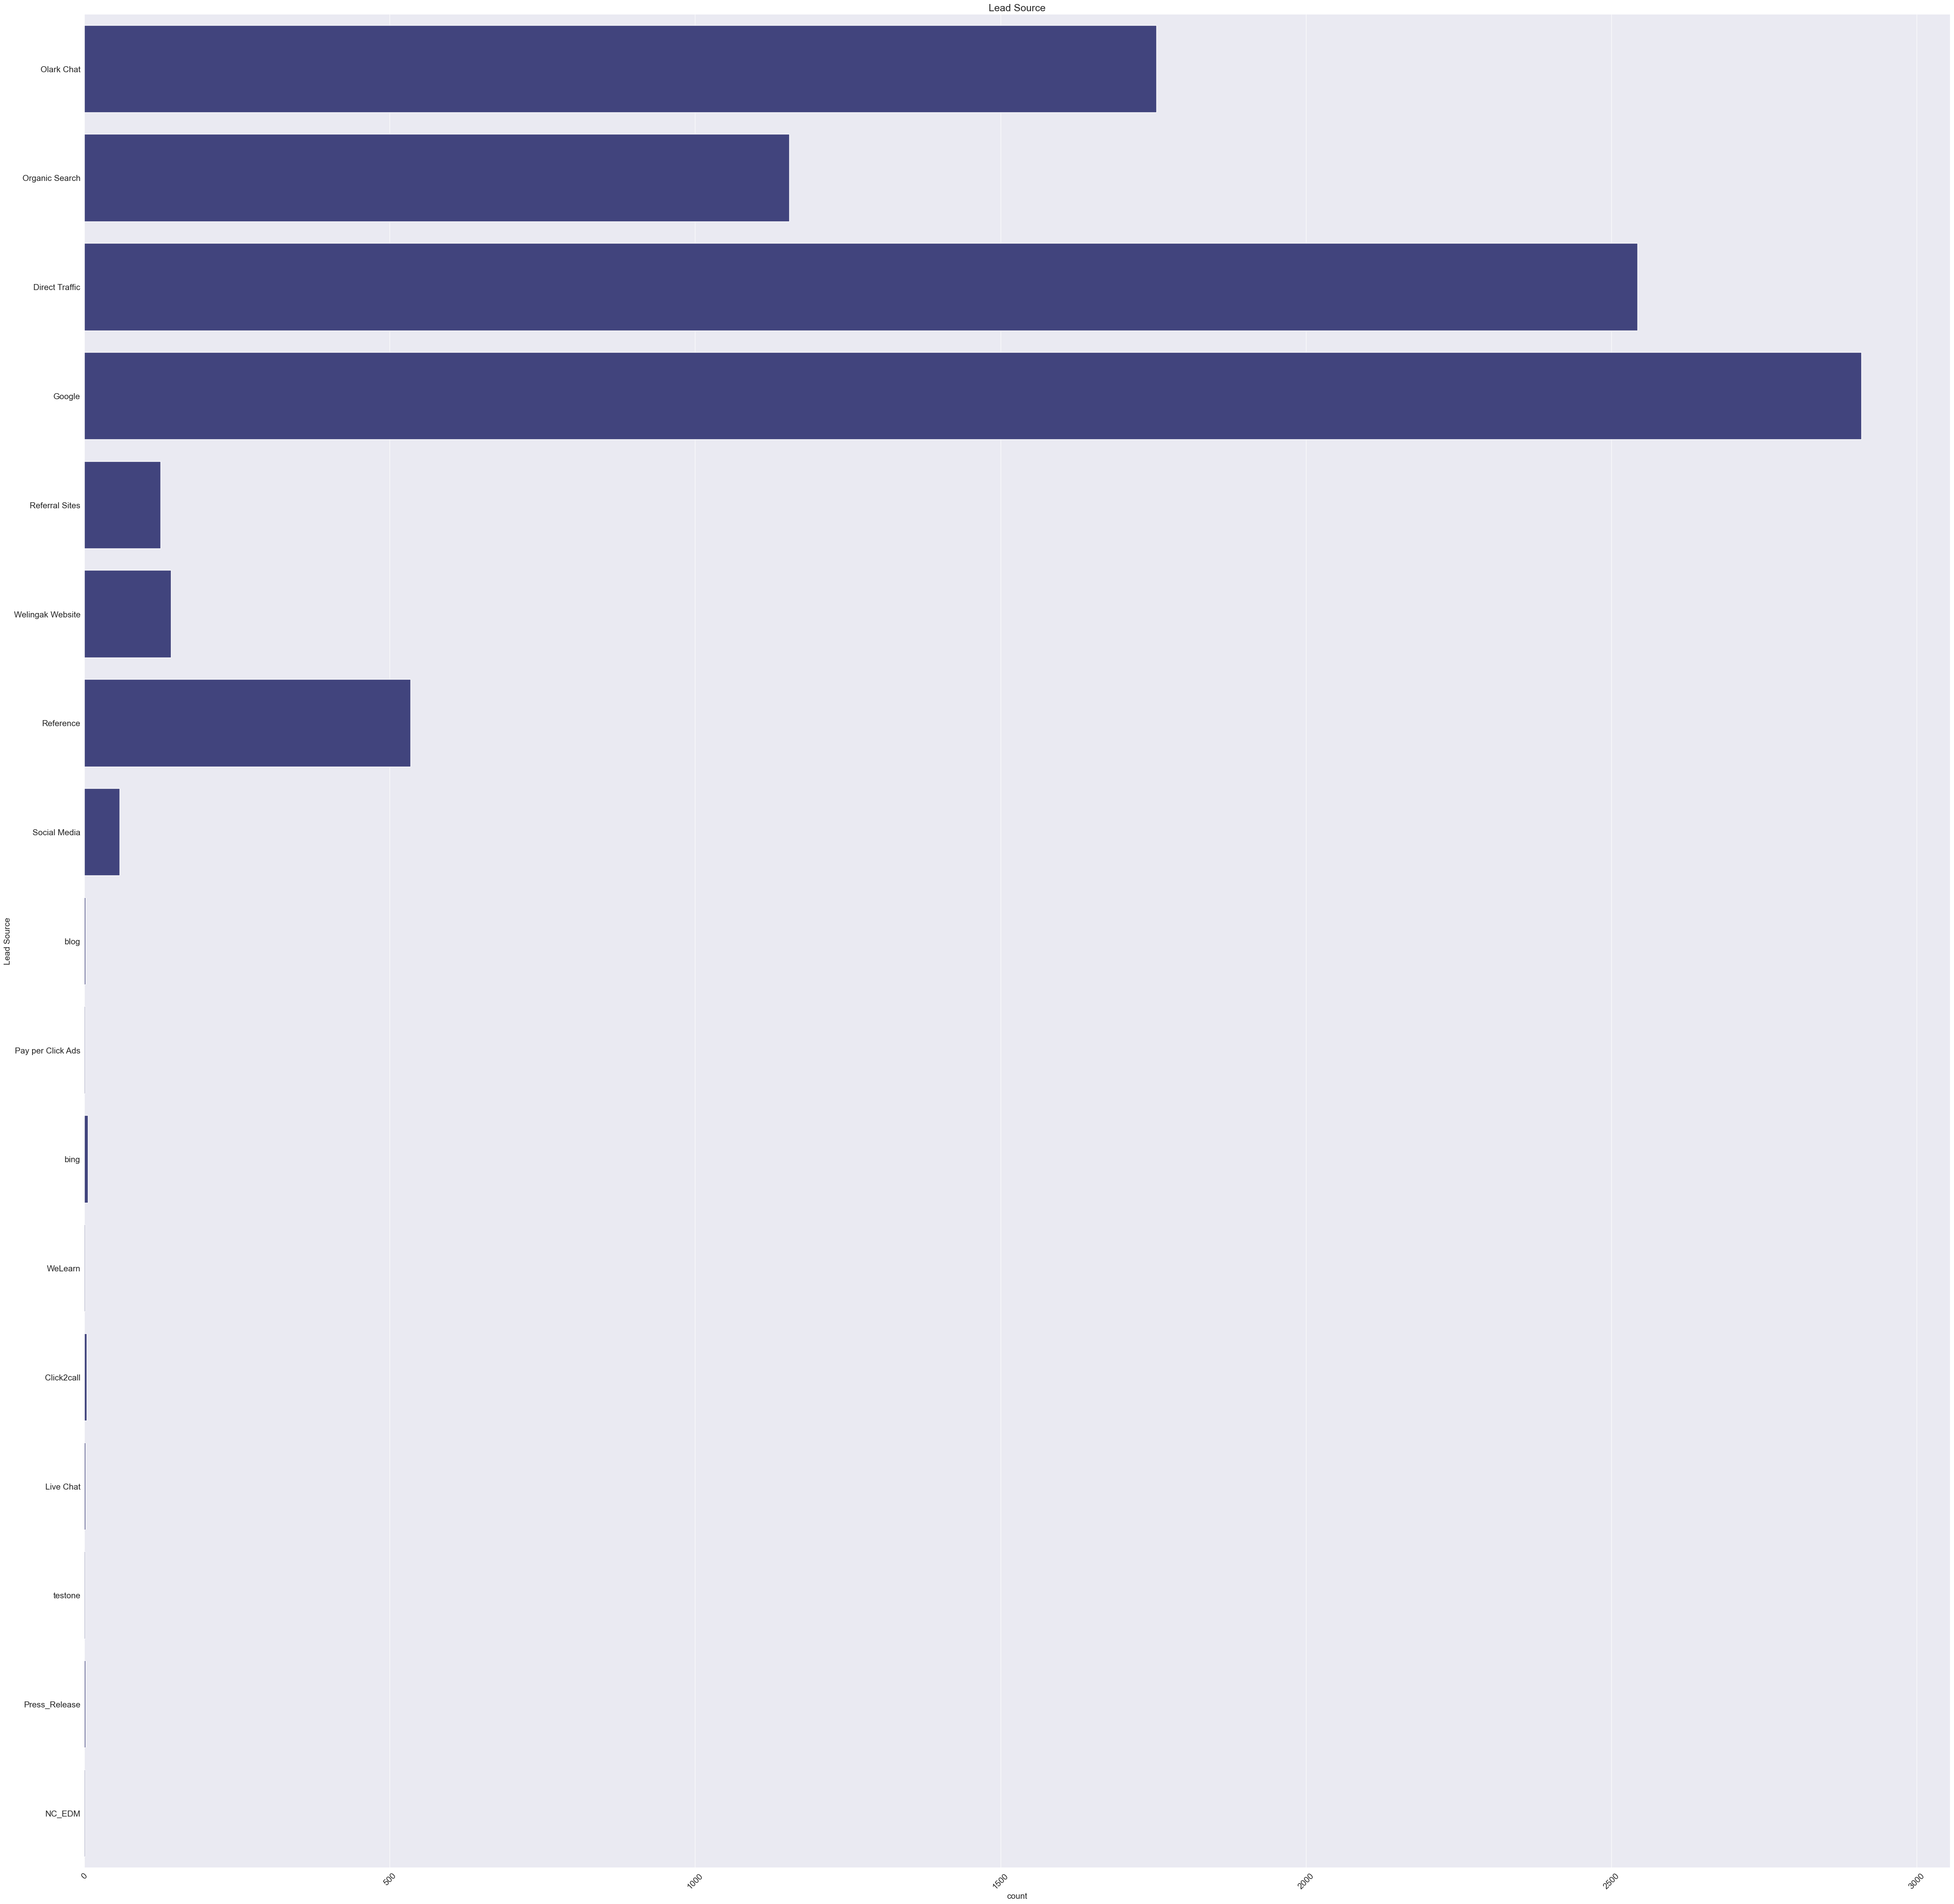

In [78]:
#bar chart counting number of leads by source.
plt.figure(figsize=(60,60))
sns.countplot(leads['Lead Source'],color = randomcolor()).set_title('Lead Source')
plt.xticks(rotation=45)
plt.show()

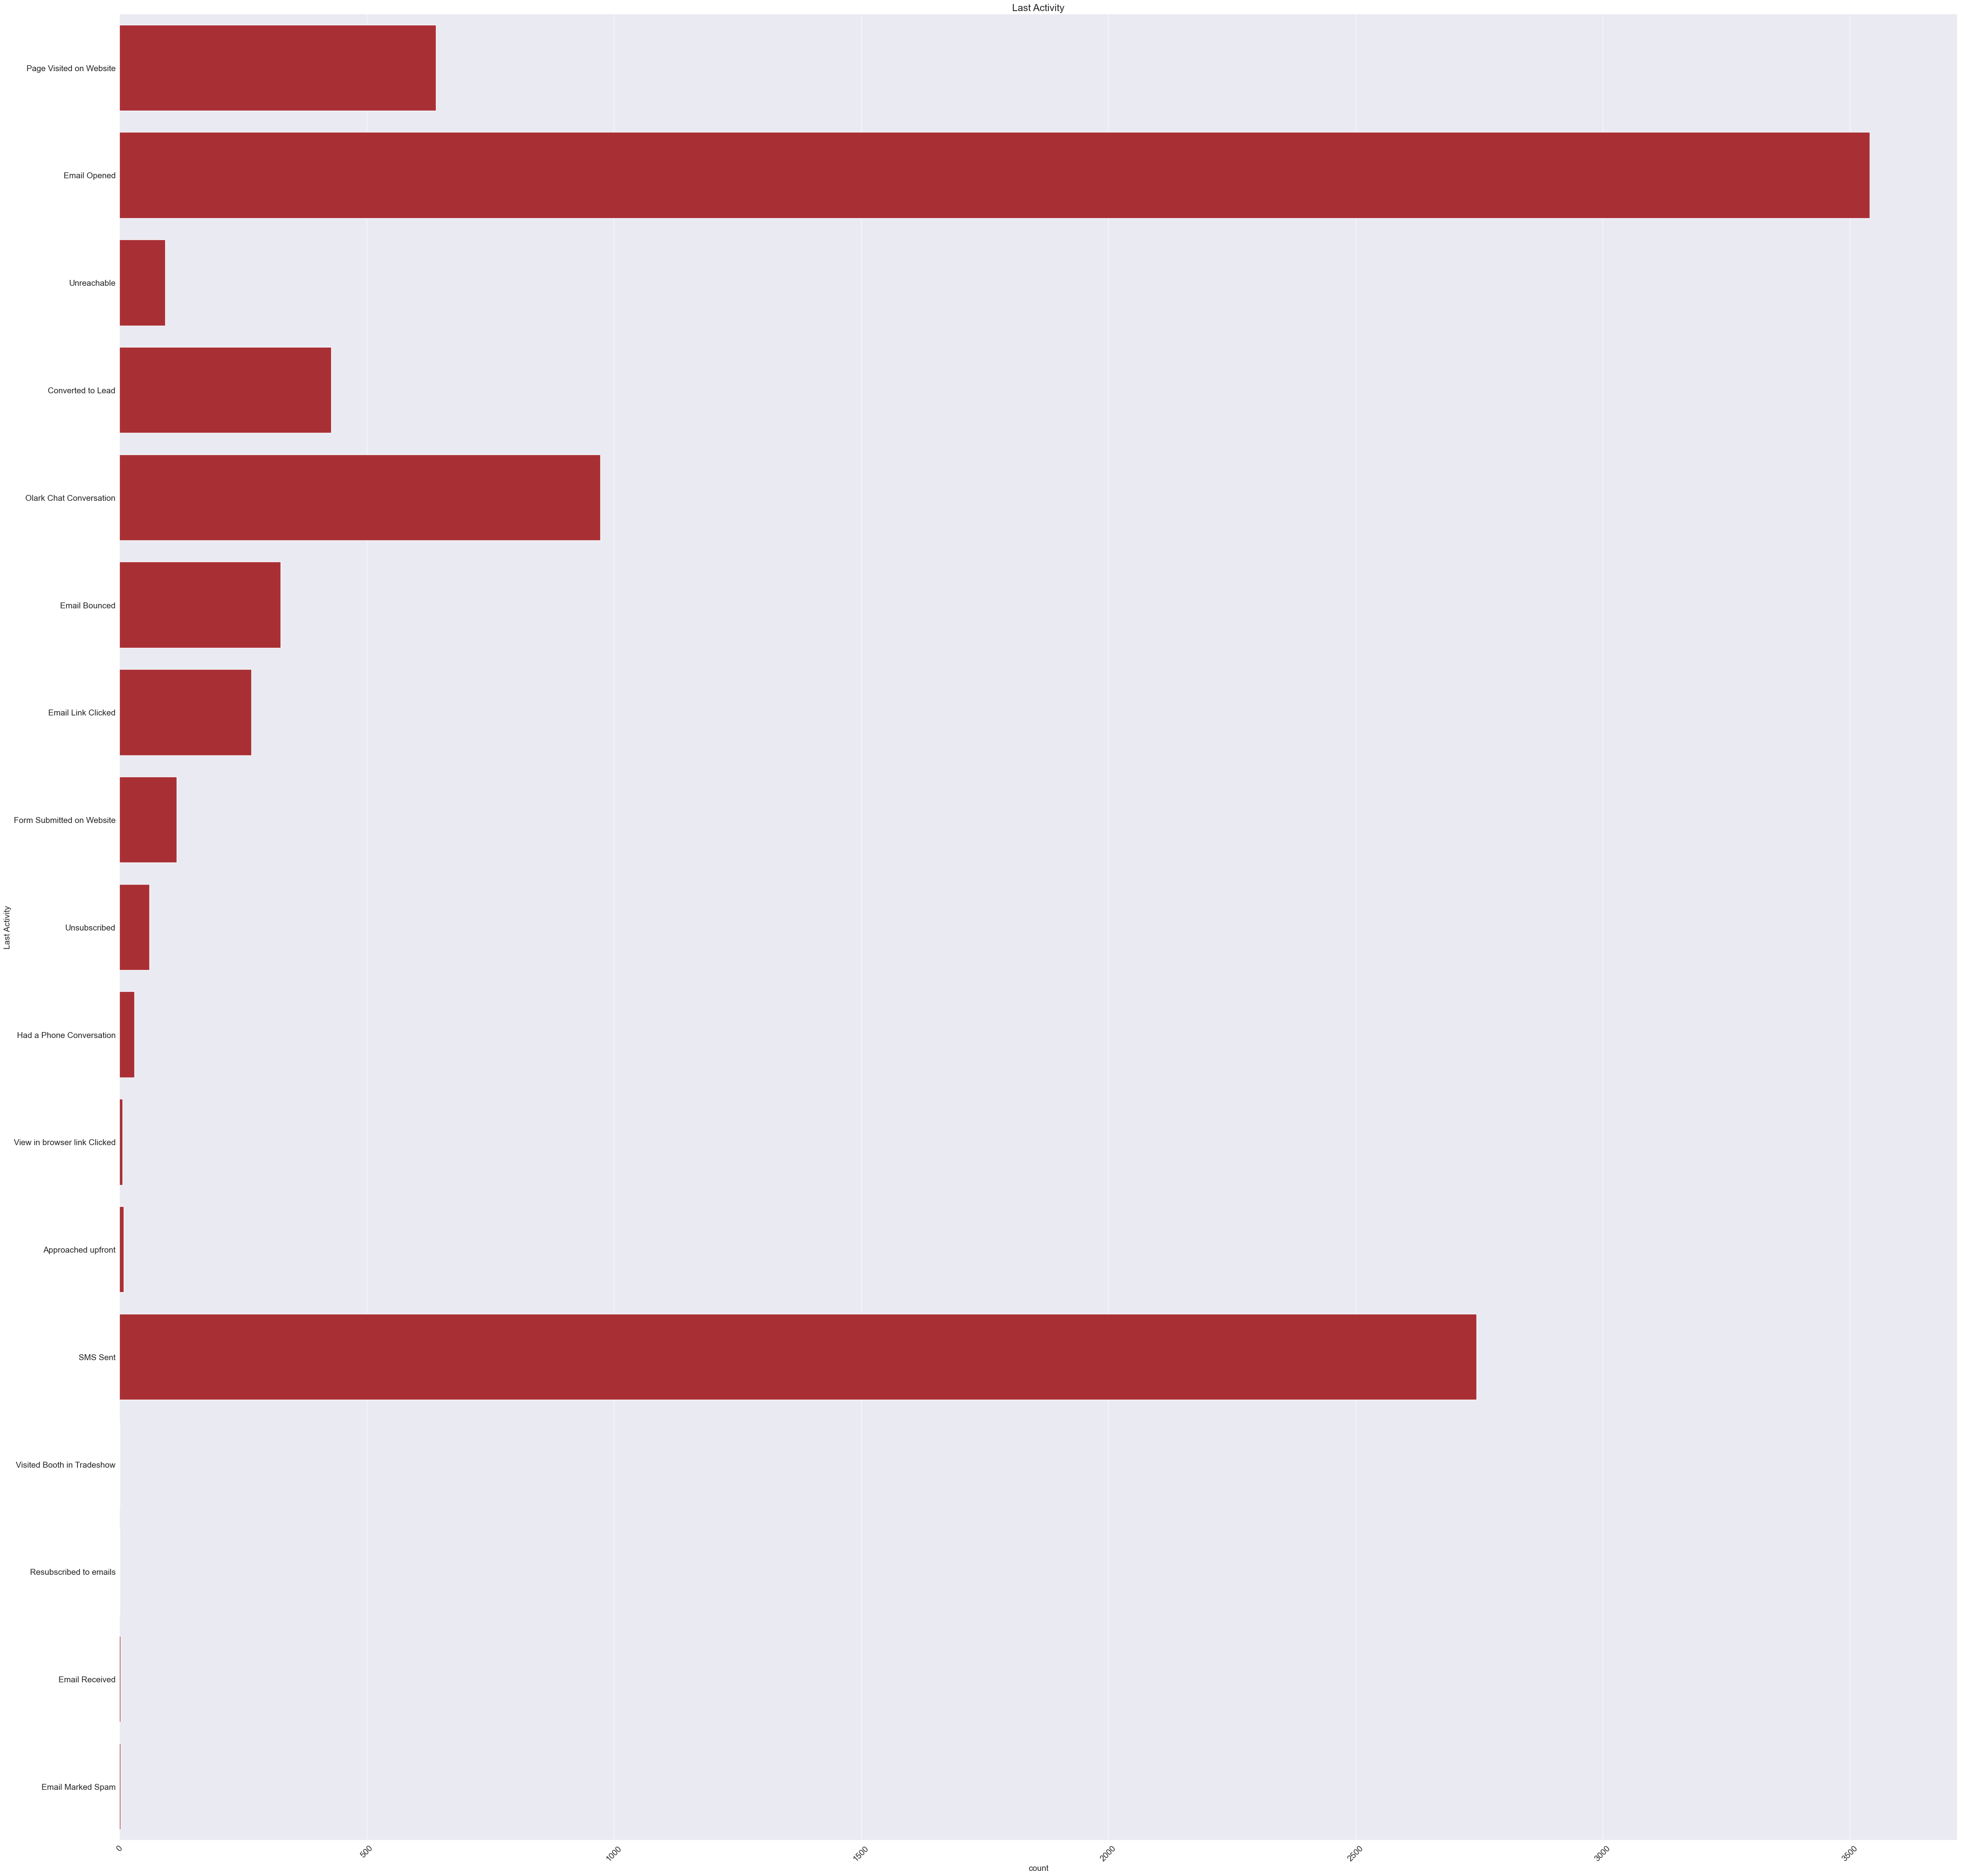

In [79]:
#bar chart counting number of leads by last activity.
plt.figure(figsize=(60,60))
sns.countplot(leads['Last Activity'],color = randomcolor()).set_title('Last Activity')
plt.xticks(rotation=45)
plt.show()

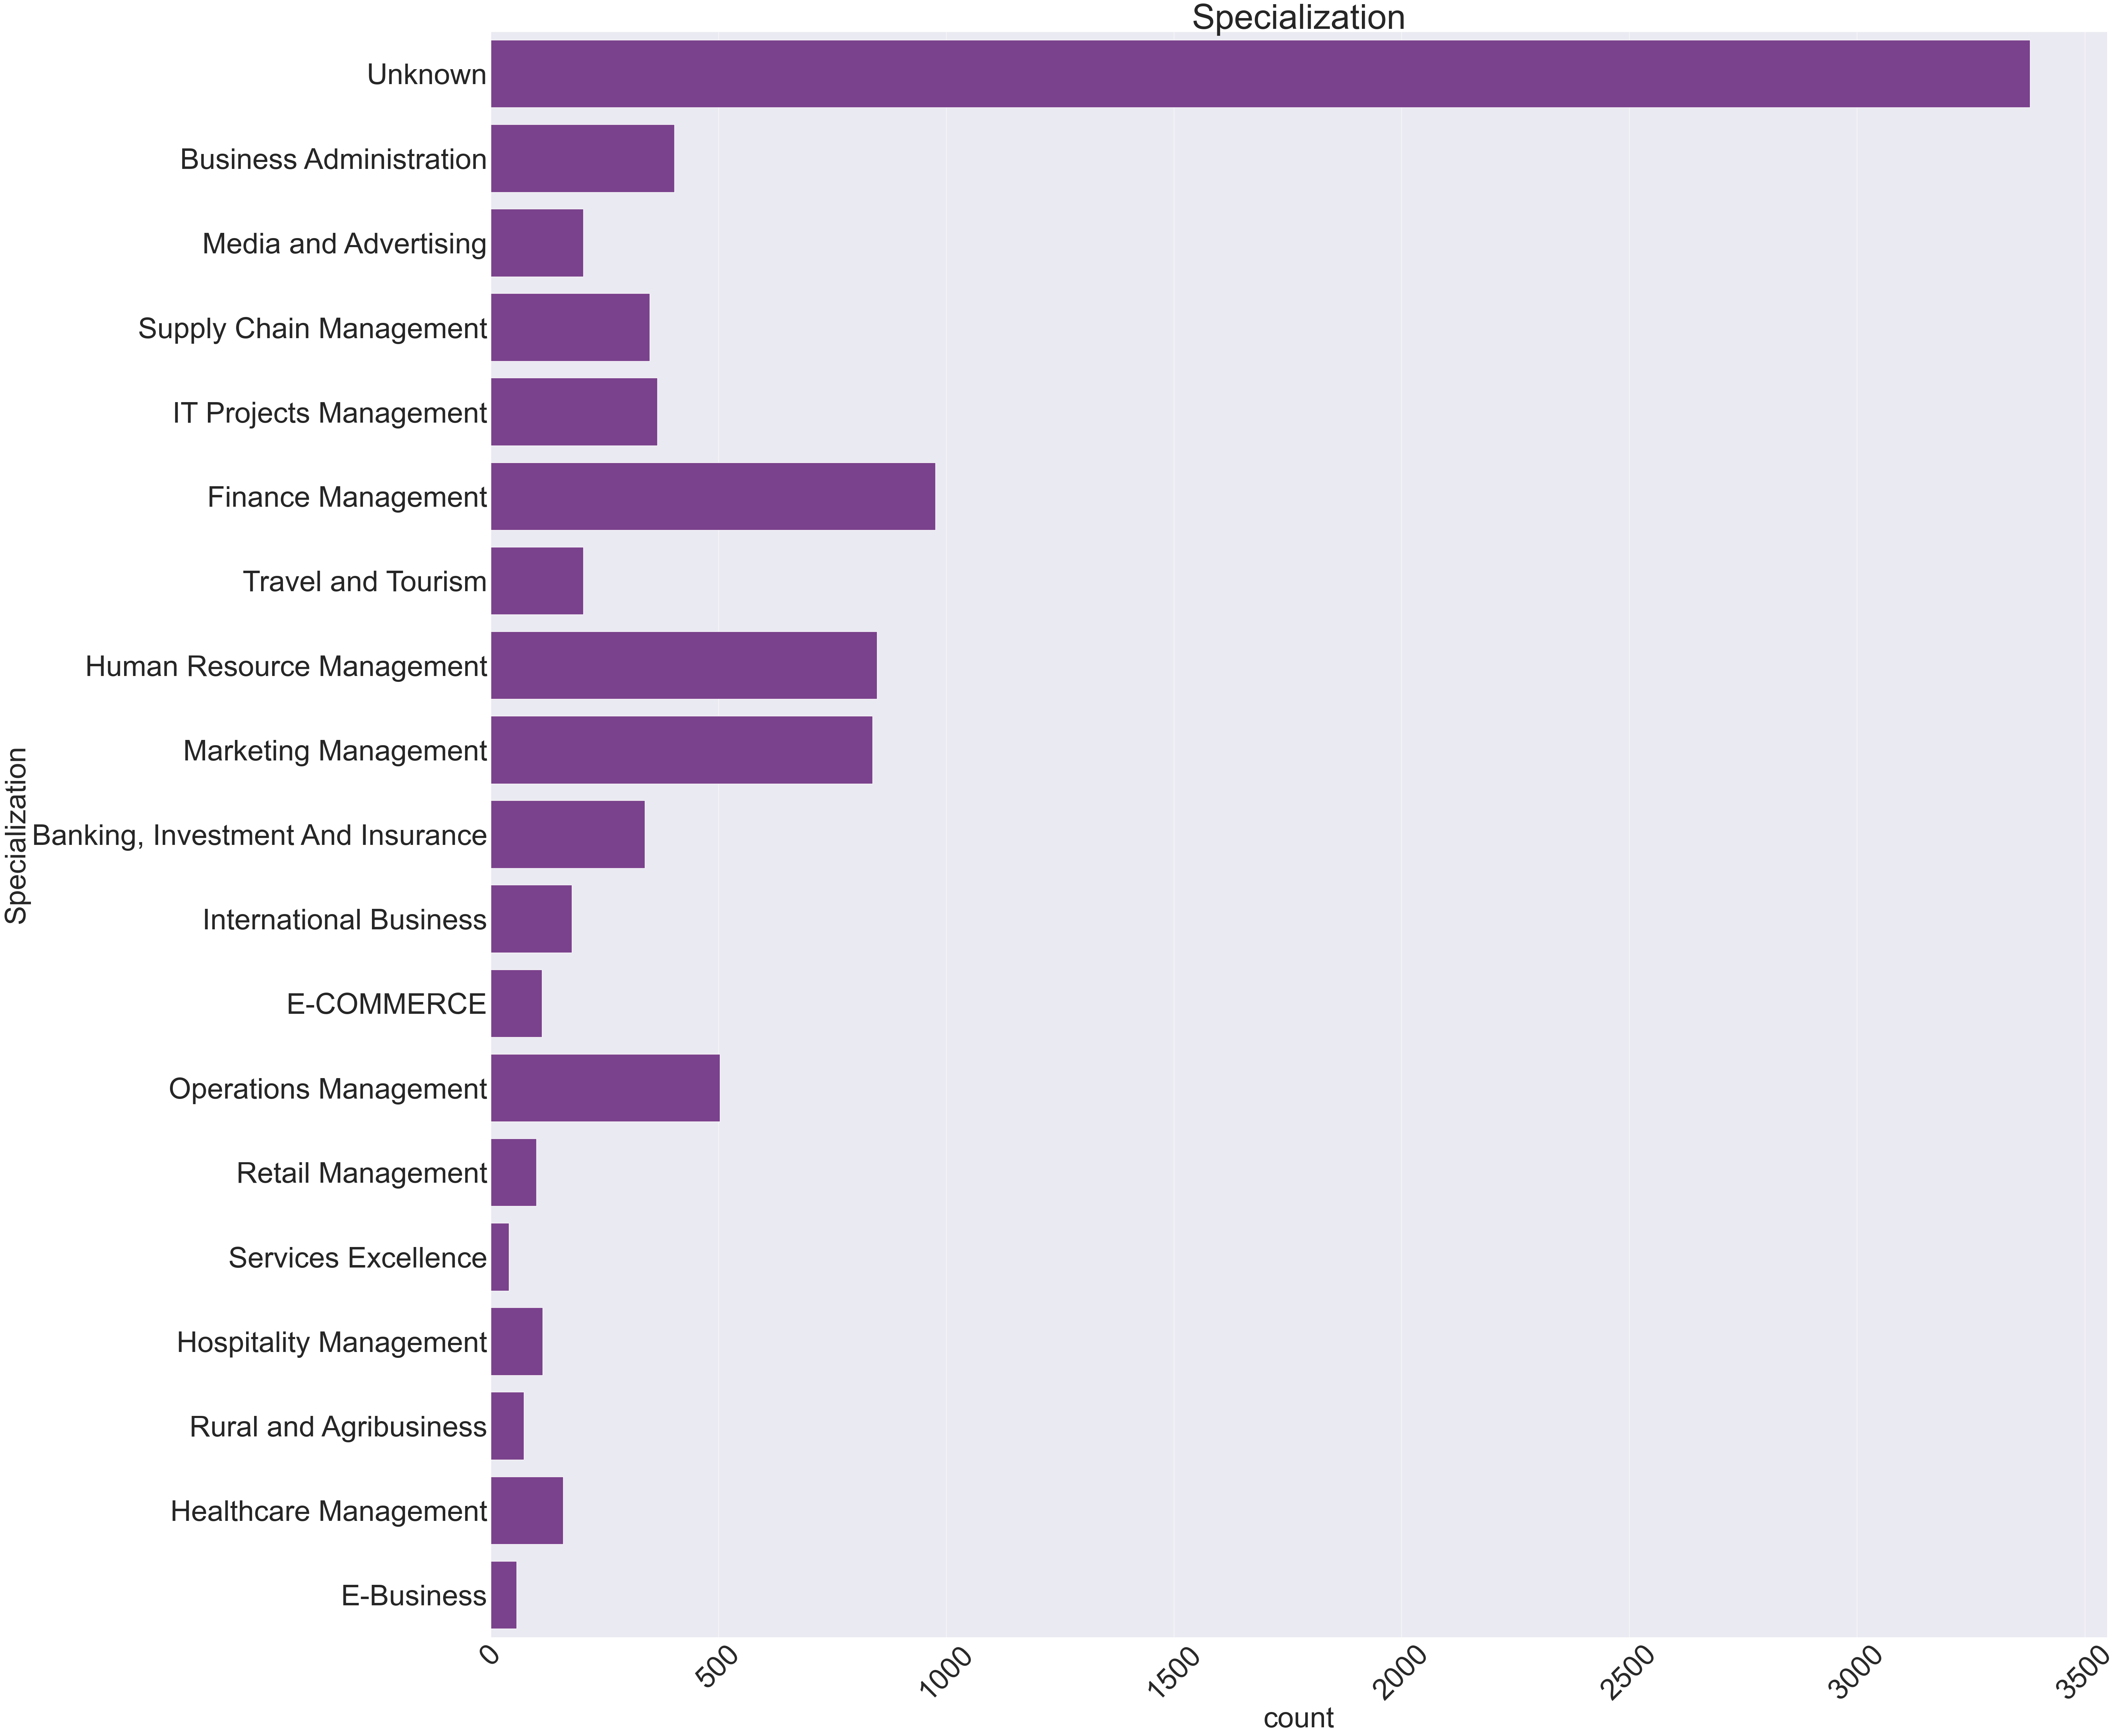

In [80]:
#bar chart counting number of leads by specialization.
plt.figure(figsize=(60,60))
plt.rcParams.update({'font.size': 60})
sns.countplot(leads['Specialization'],color = randomcolor()).set_title('Specialization')
plt.xticks(rotation=45)
plt.show()

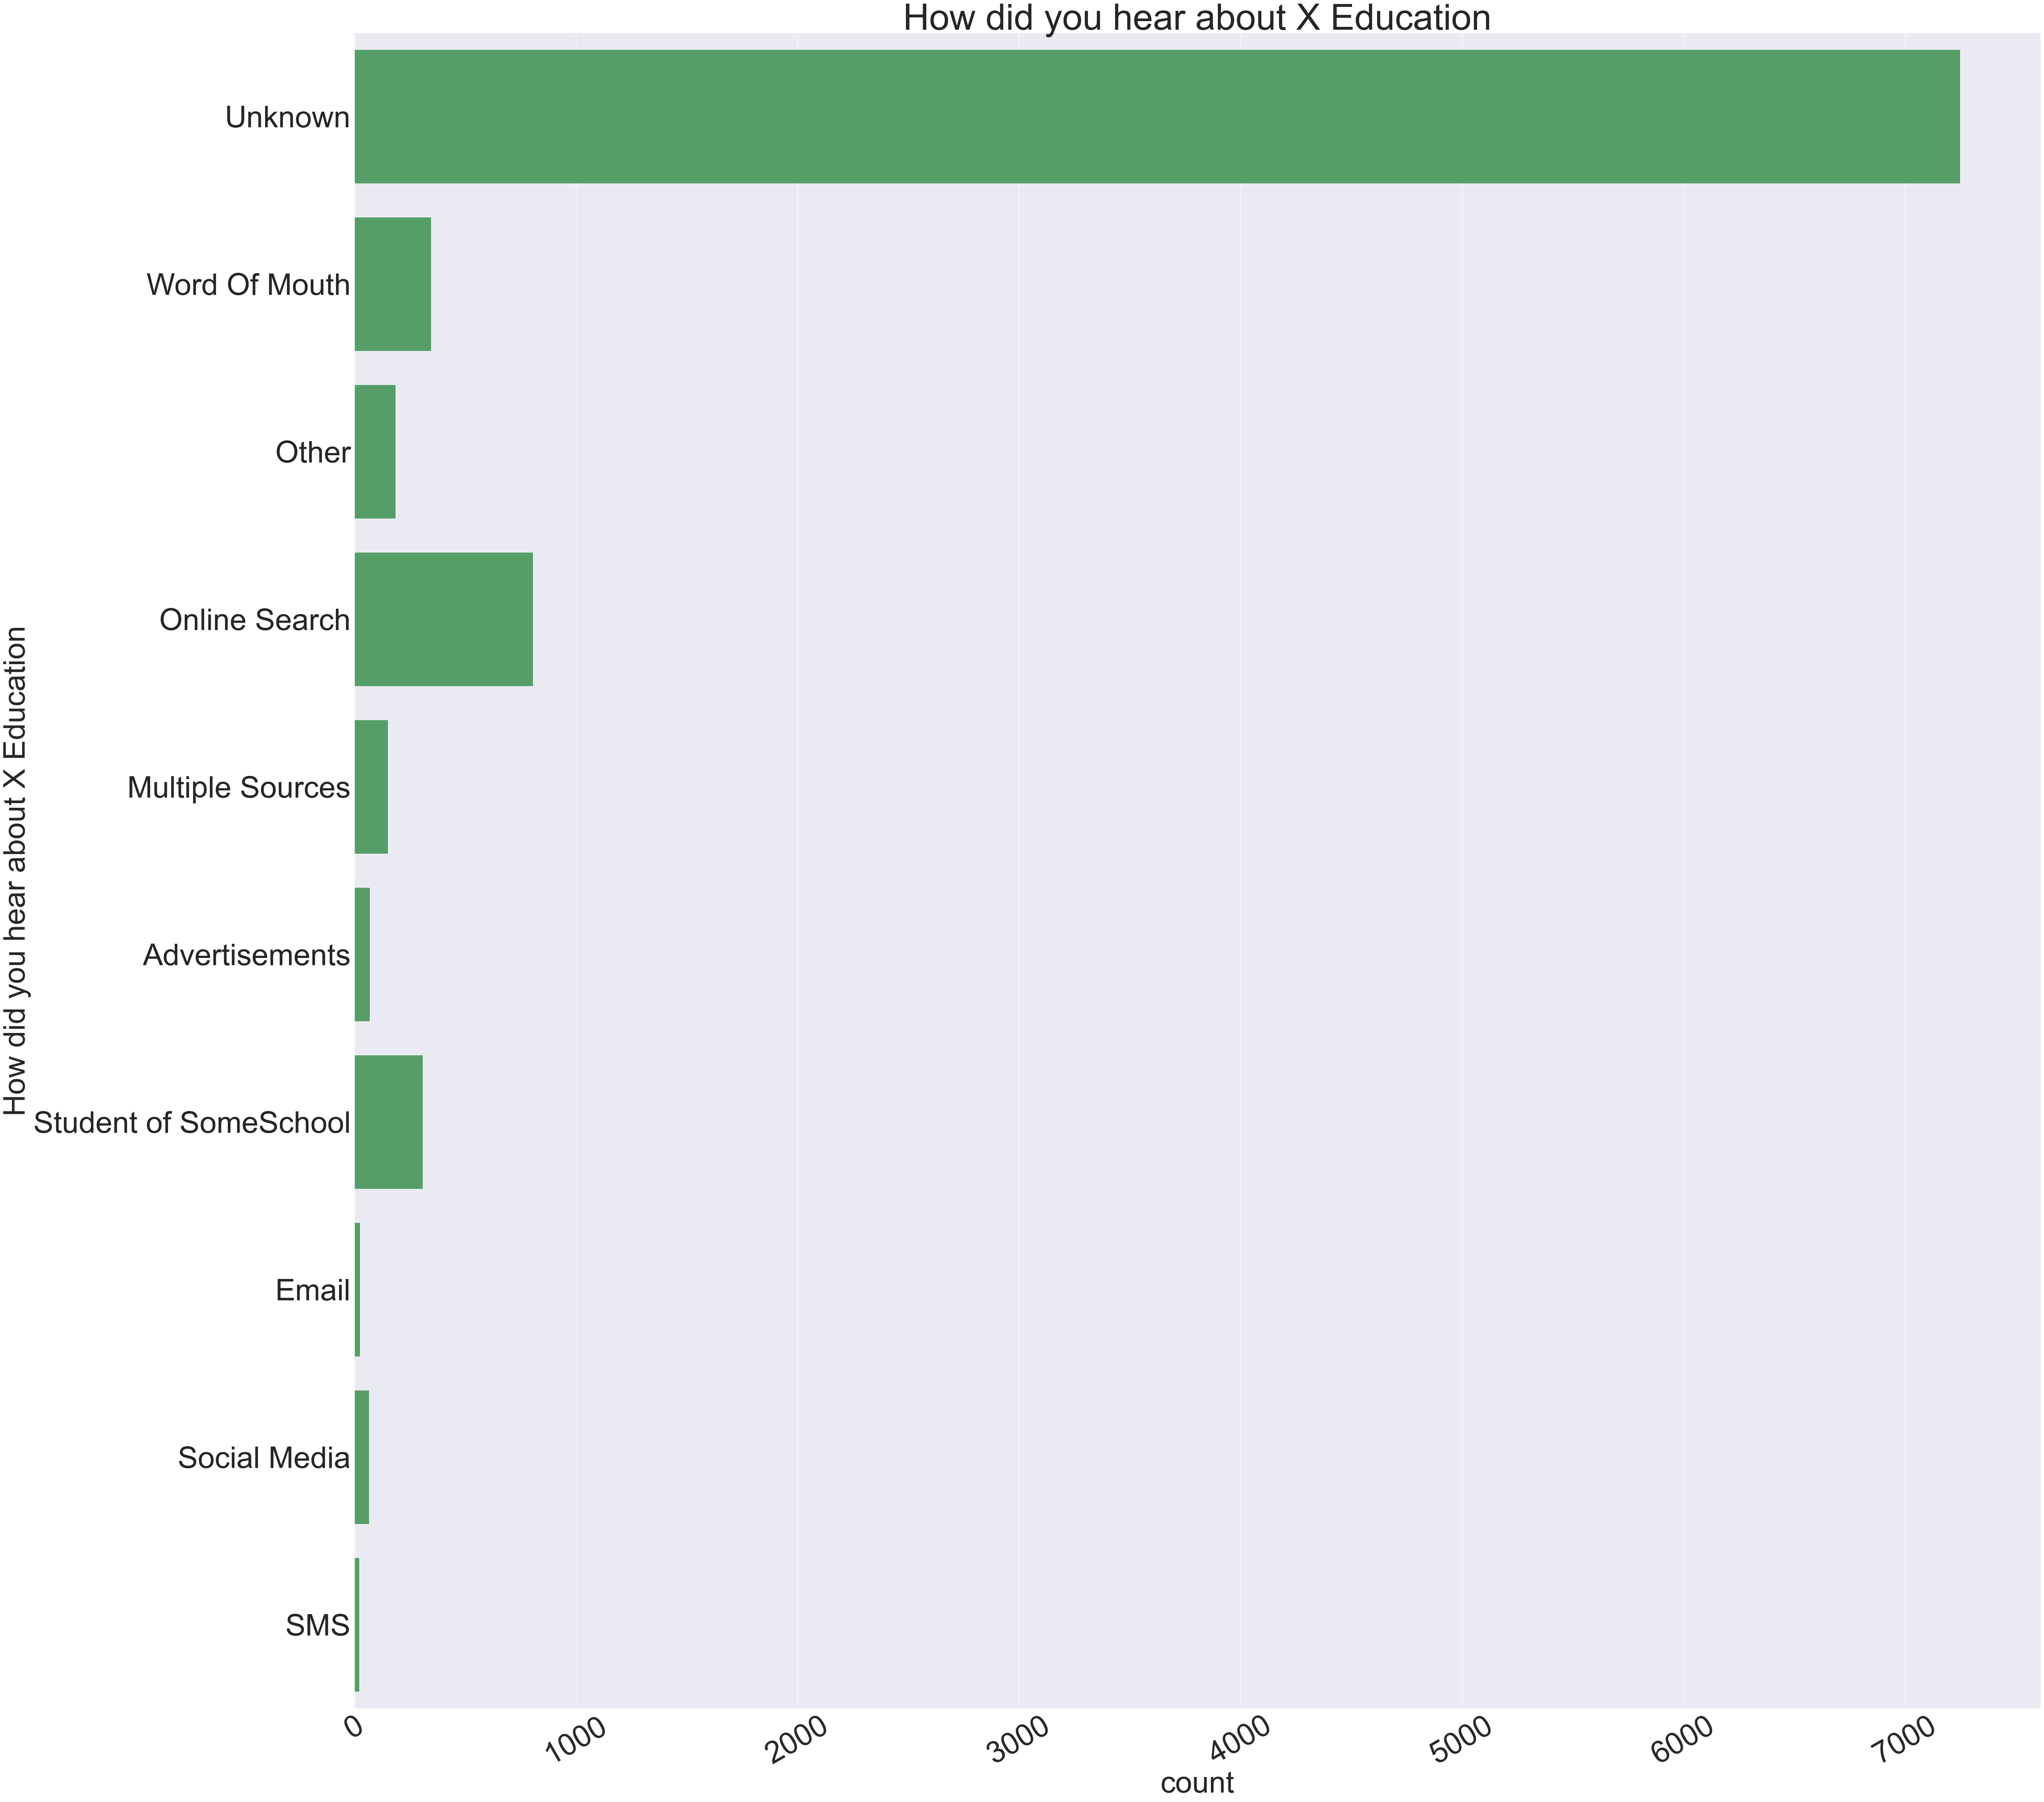

In [81]:
#bar chart counting number of leads by what informed them about the company.
plt.figure(figsize=(60,60))
sns.countplot(leads['How did you hear about X Education'],color = randomcolor()).set_title('How did you hear about X Education')
plt.xticks(rotation=30)
plt.show()

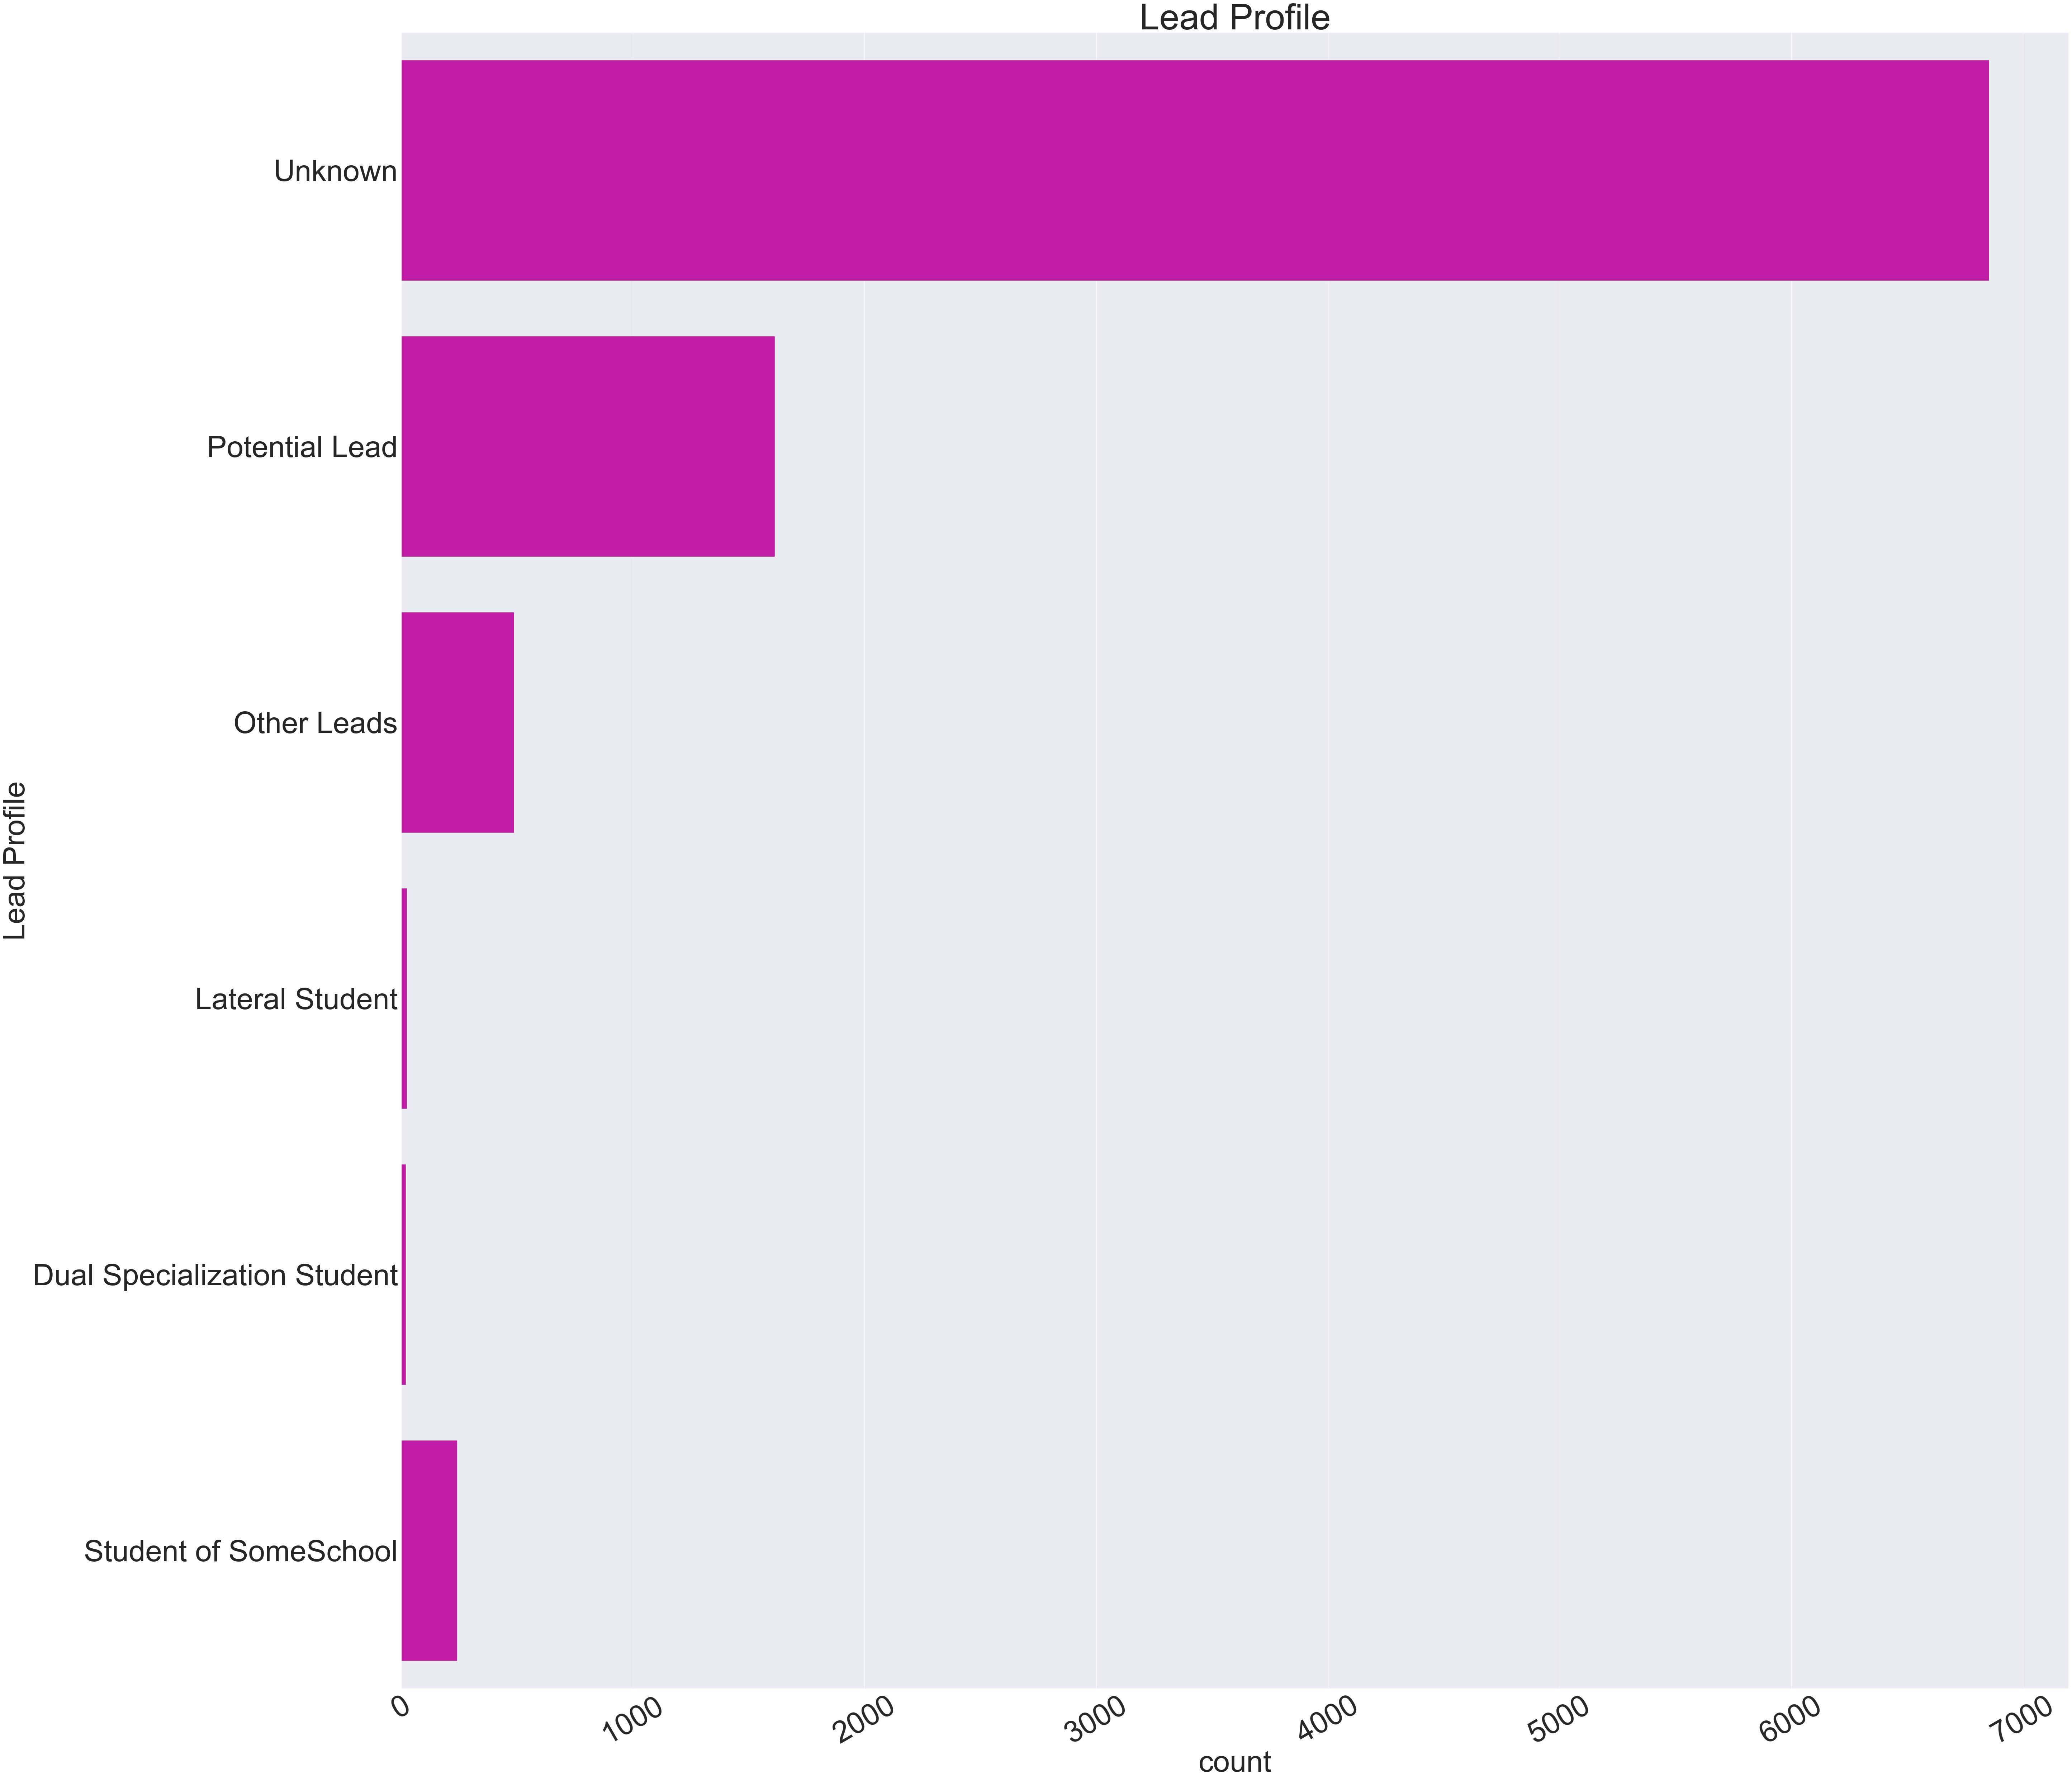

In [82]:
#bar chart counting number of leads by profile.
plt.figure(figsize=(60,60))
sns.countplot(leads['Lead Profile'],color = randomcolor()).set_title('Lead Profile')
plt.xticks(rotation=30)
plt.show()

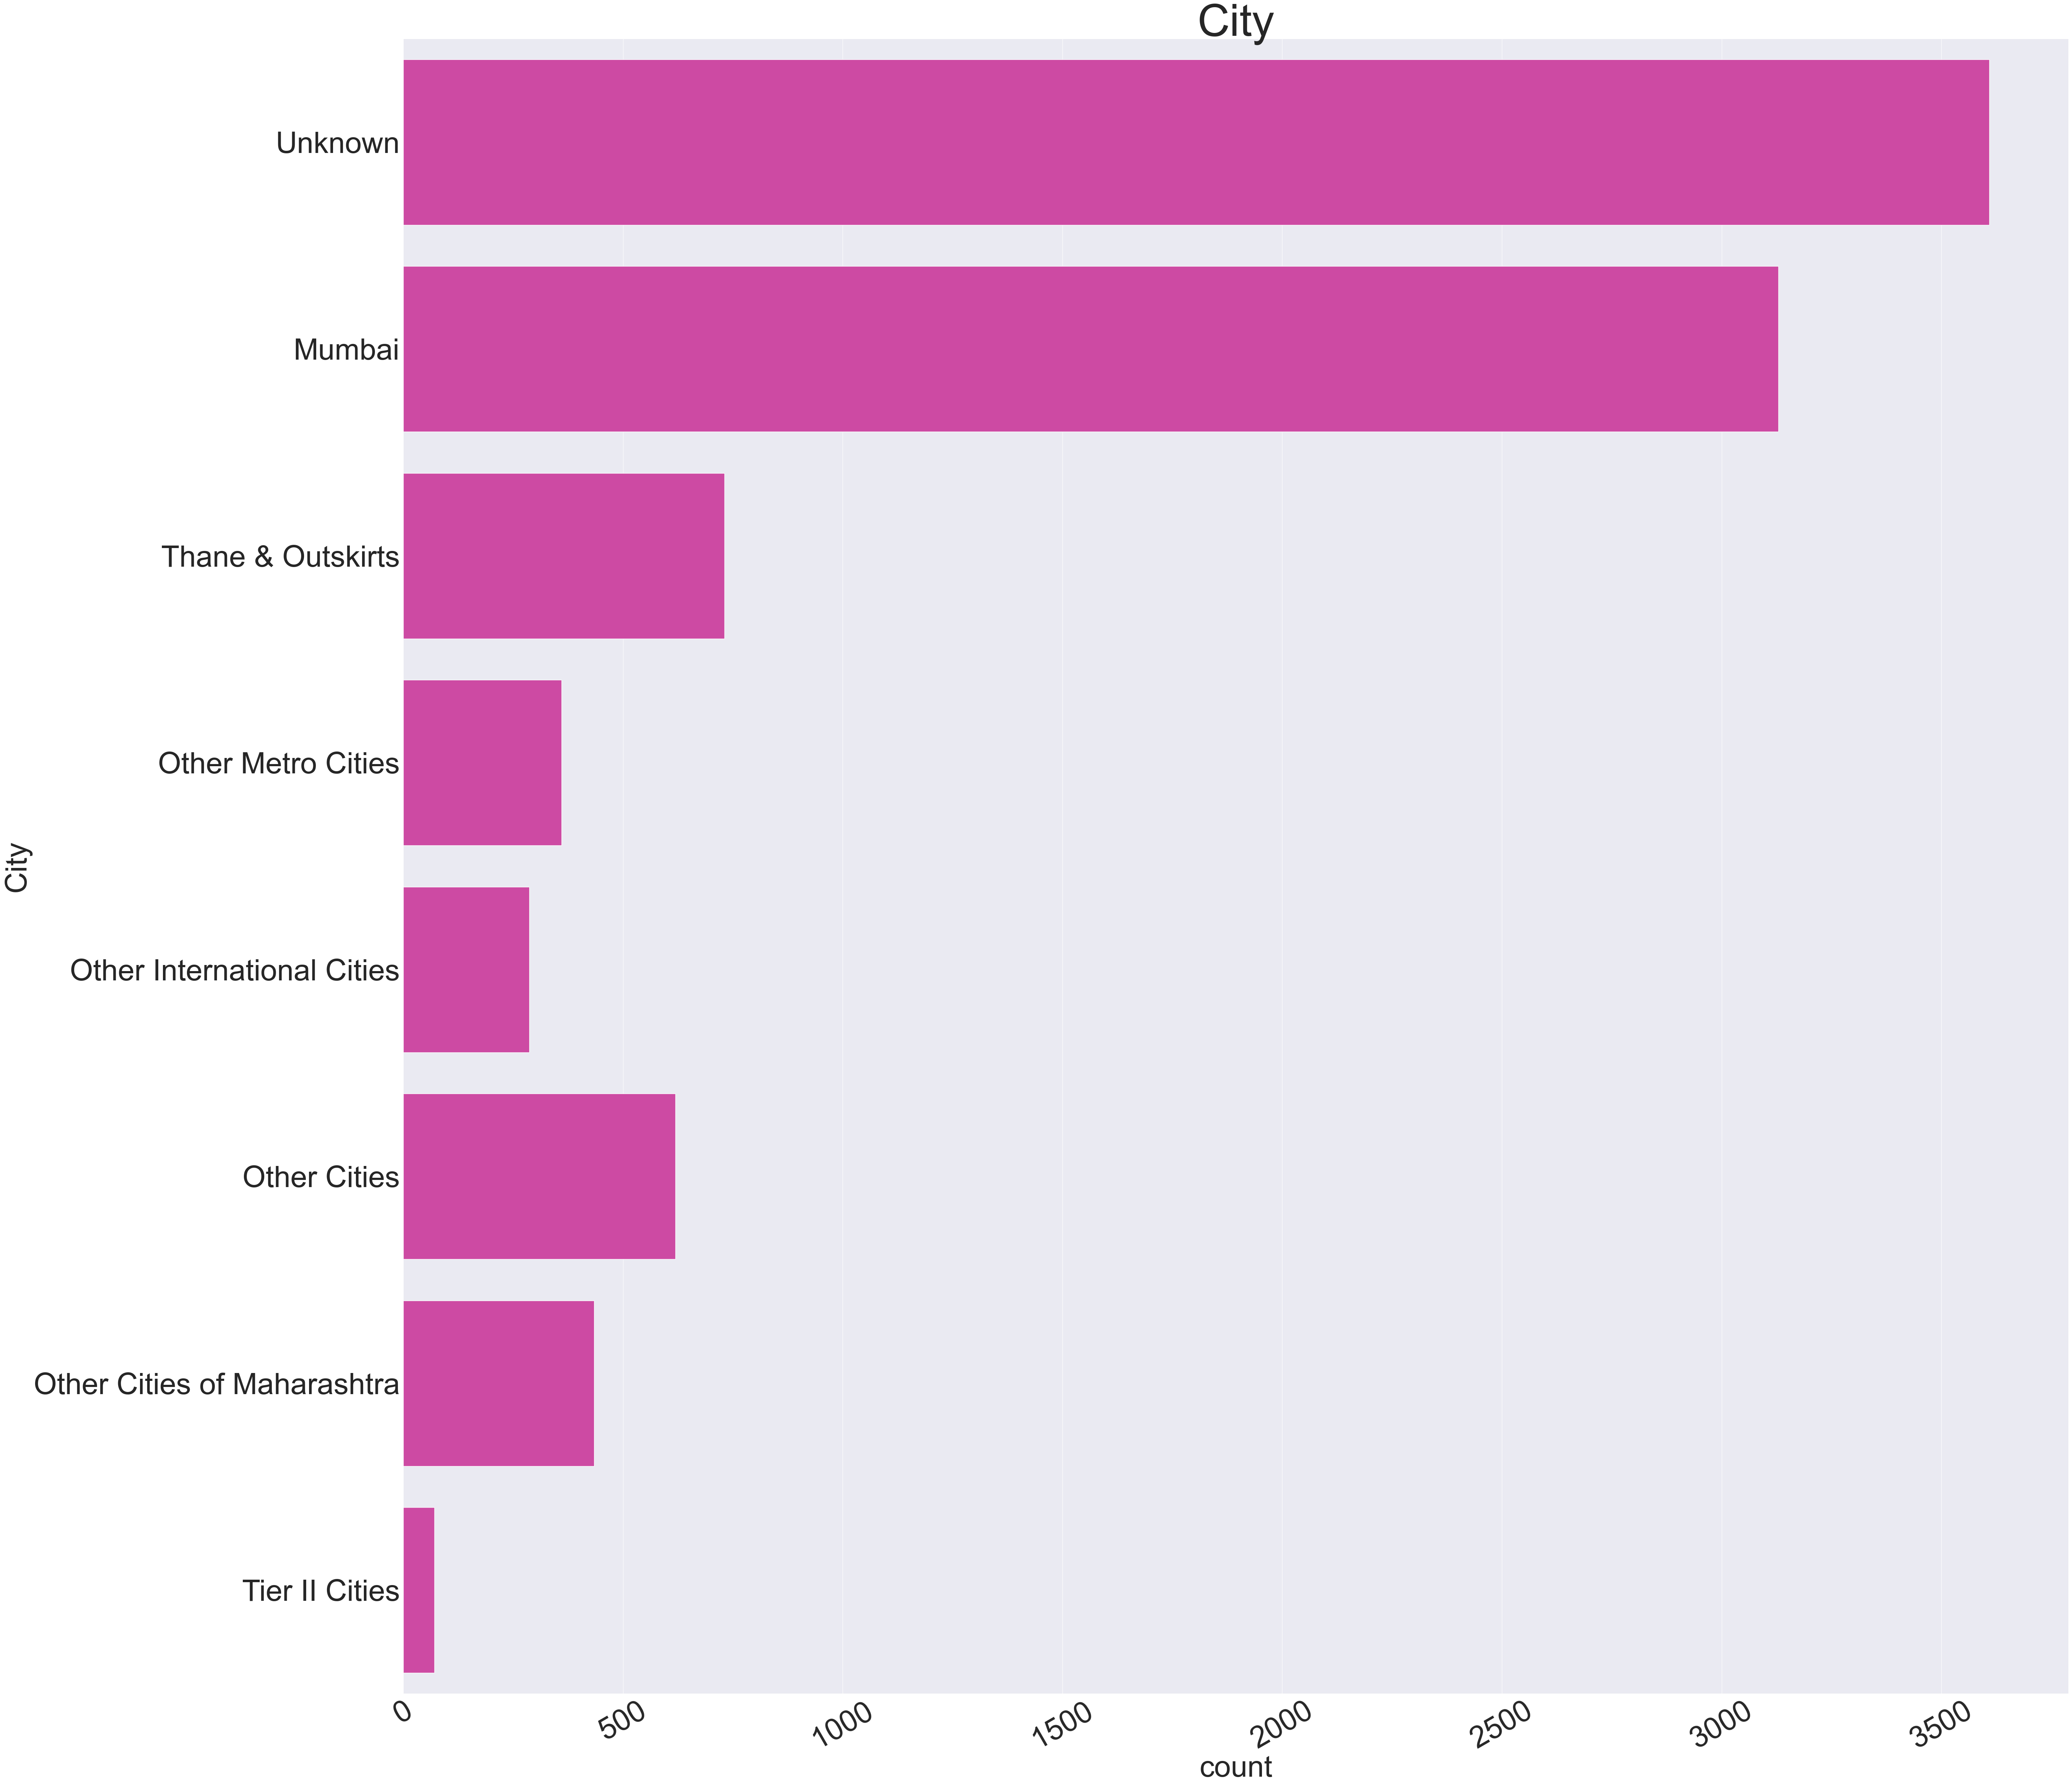

In [83]:
#bar chart counting number of leads by city.
plt.figure(figsize=(60,60))
sns.countplot(leads['City'],color = randomcolor()).set_title('City',size=90)
plt.xticks(rotation=30)
plt.show()

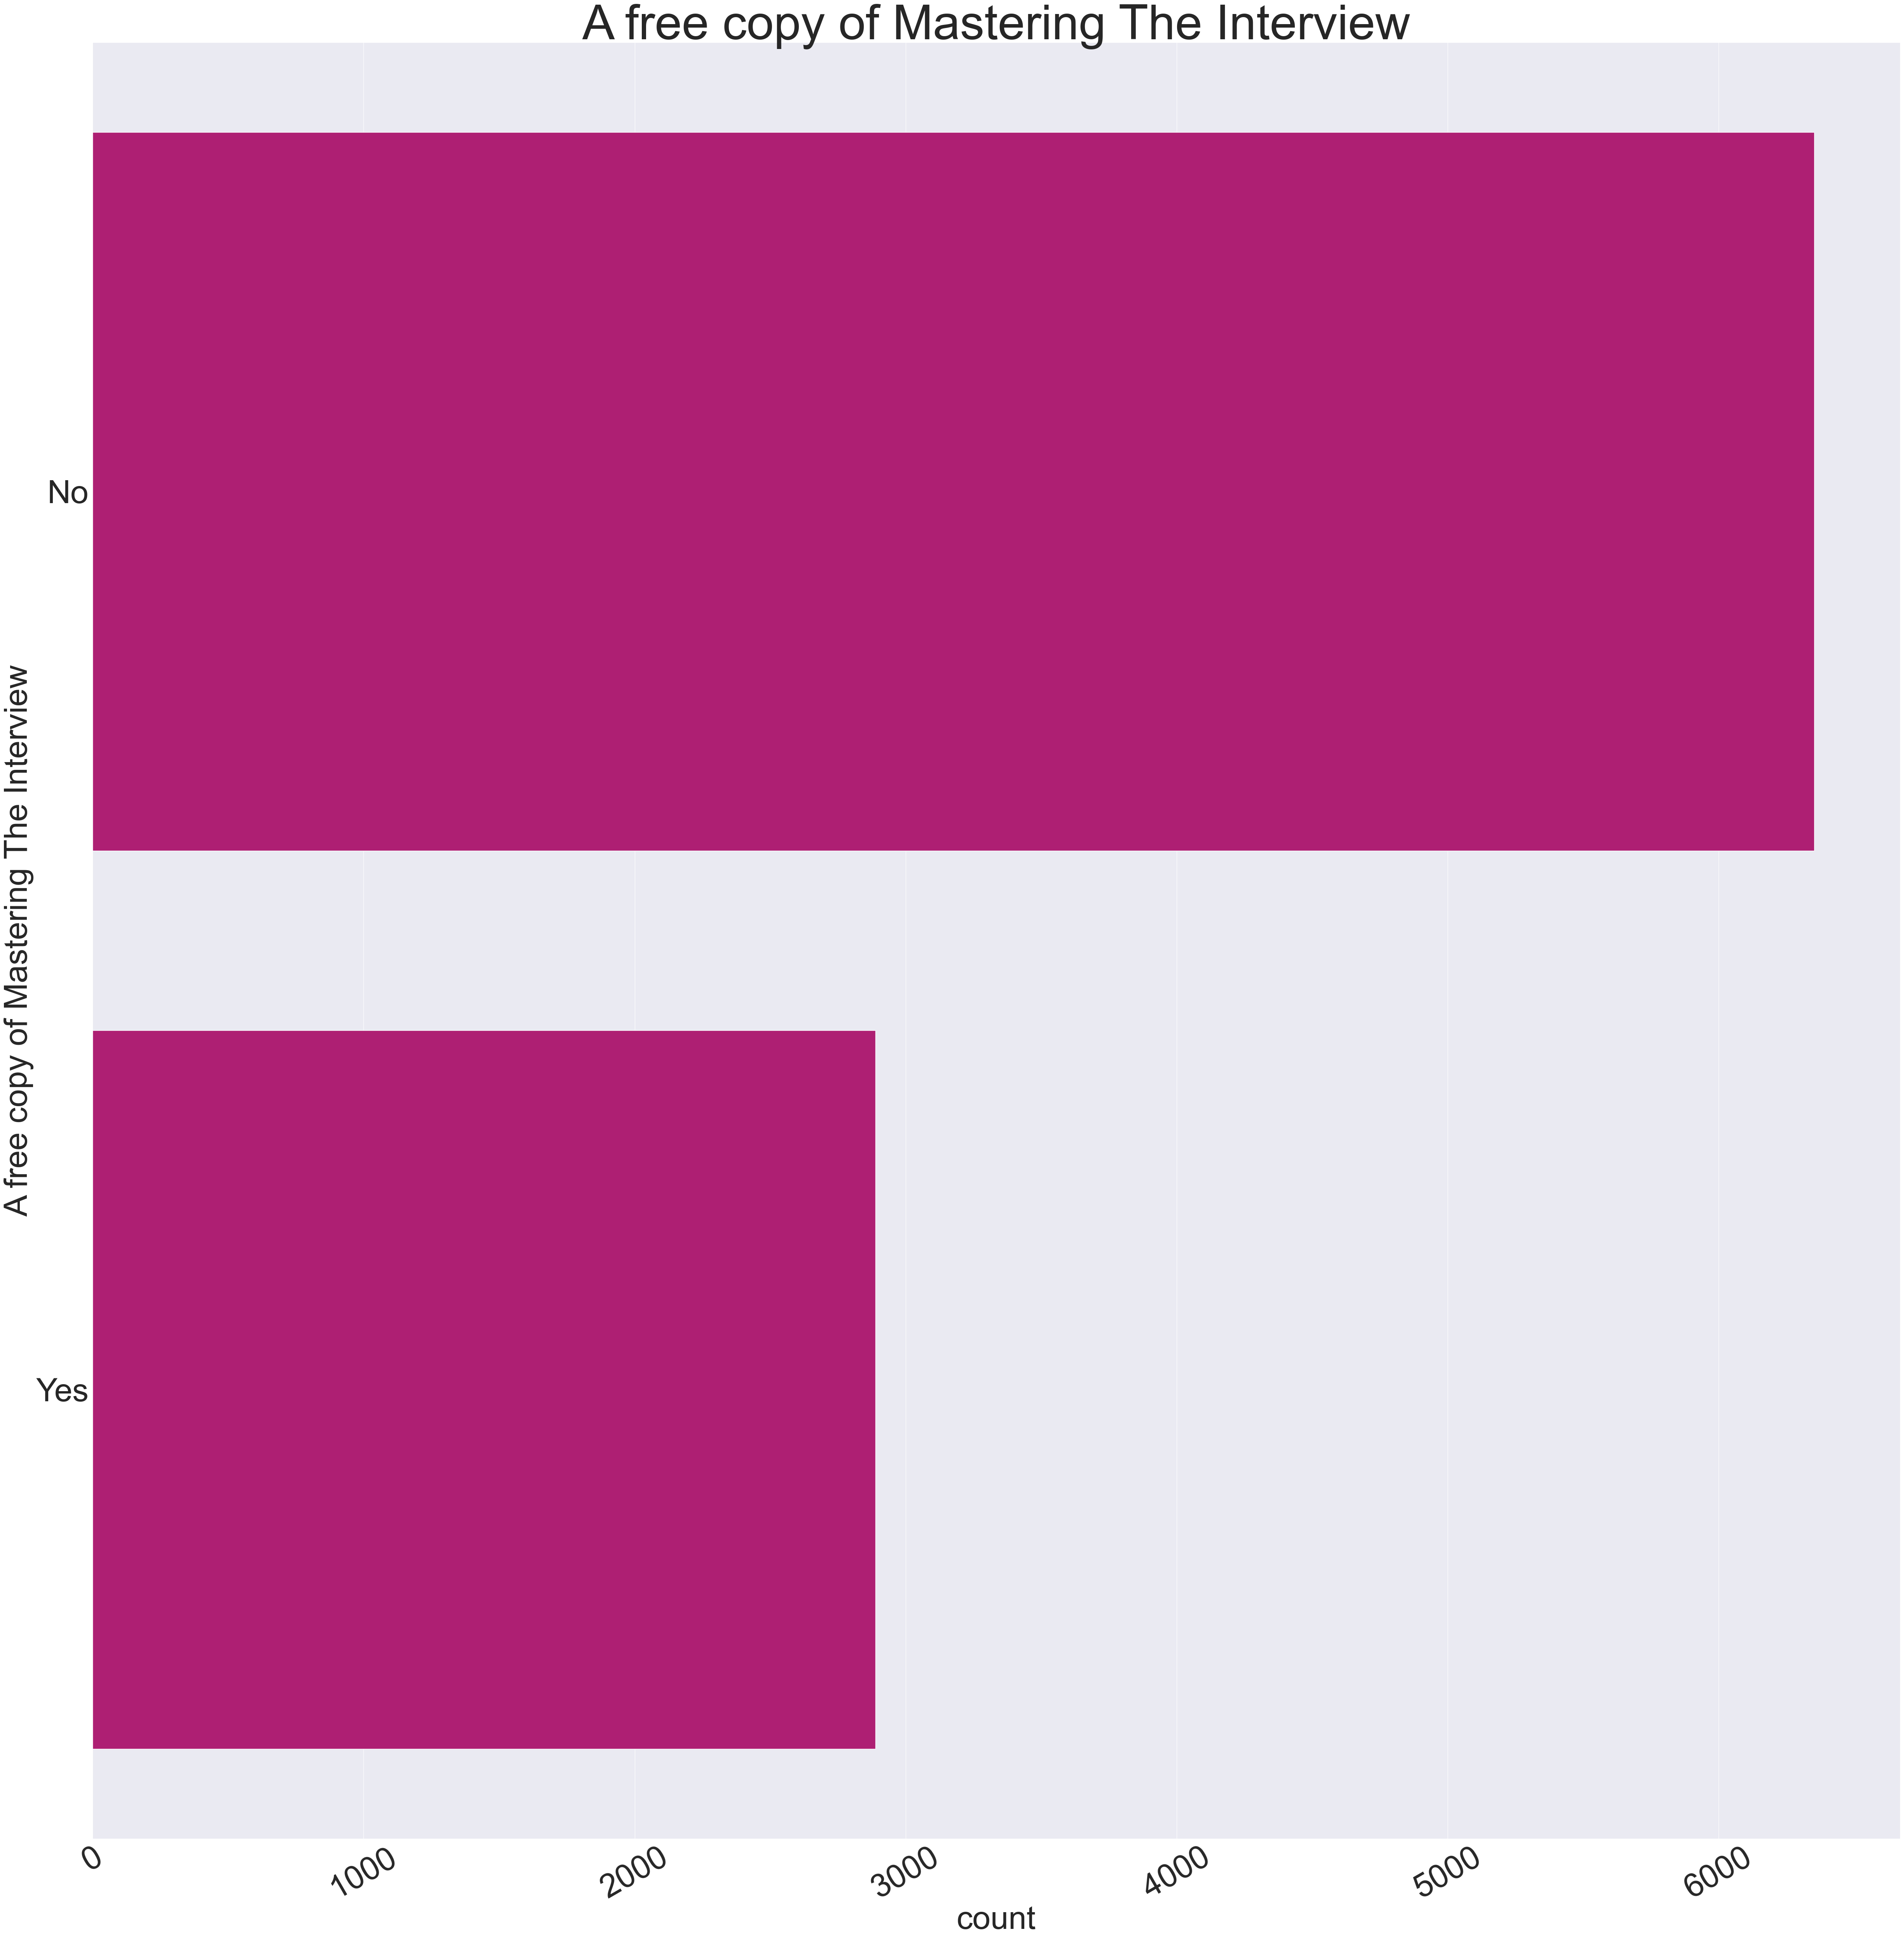

In [84]:
#bar chart counting number of leads by whether they want a free copy of a book or not.
plt.figure(figsize=(60,60))
sns.countplot(leads['A free copy of Mastering The Interview'],color = randomcolor()).set_title('A free copy of Mastering The Interview',size=90)
plt.xticks(rotation=30)
plt.show()

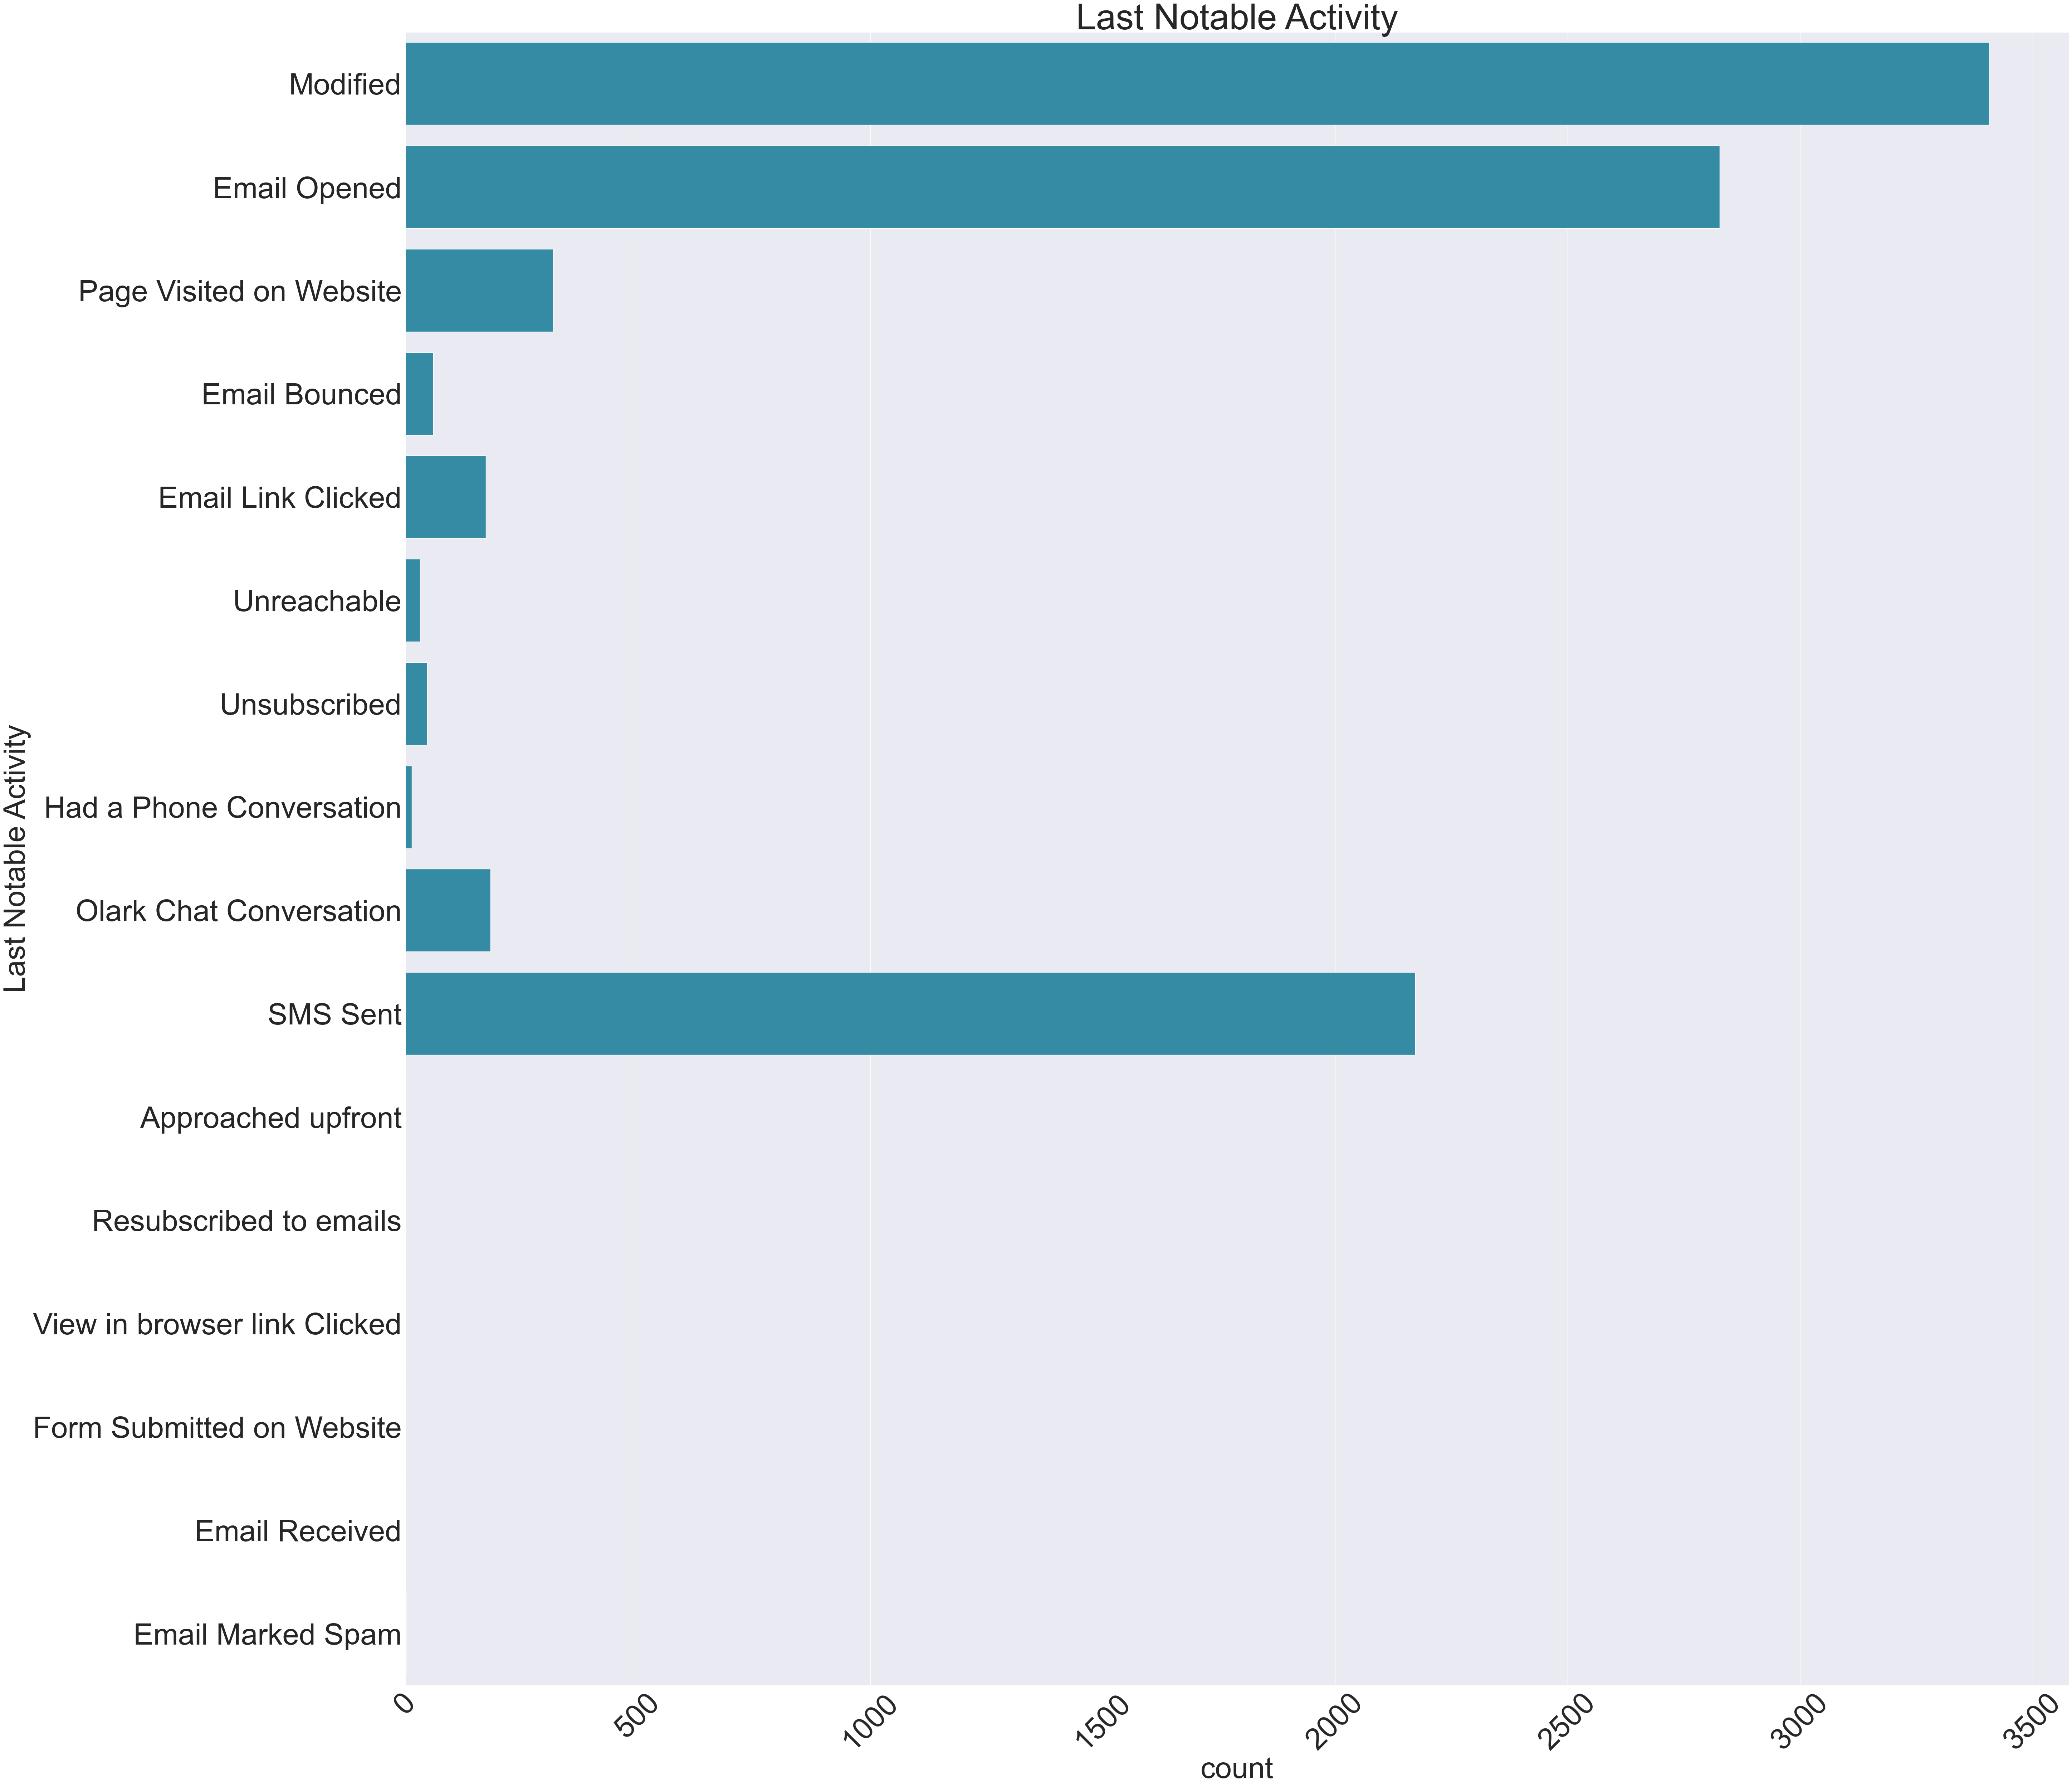

In [85]:
#bar chart counting number of leads by last notable activity.
plt.figure(figsize=(60,60))
sns.countplot(leads['Last Notable Activity'],color = randomcolor()).set_title('Last Notable Activity')
plt.xticks(rotation=45)
plt.show()

#### Checking the contributions of each category in conversion status.

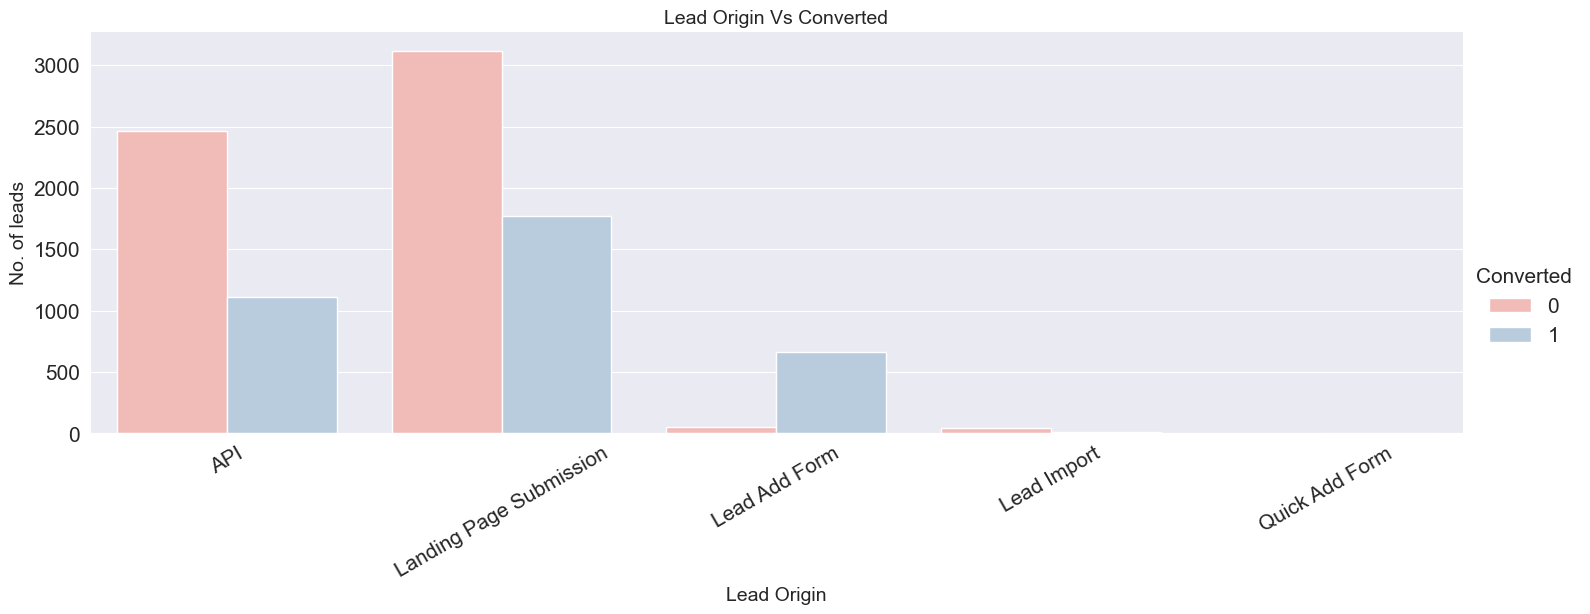

In [87]:
plt.rcParams.update({'font.size': 15})
plot = sns.catplot(x="Lead Origin", hue = "Converted", kind="count", data=leads, palette="Pastel1", aspect = 3);
plt.title('Lead Origin Vs Converted', fontsize = 14)
plt.xlabel("Lead Origin", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

Landing Page submission contributes most to both categories

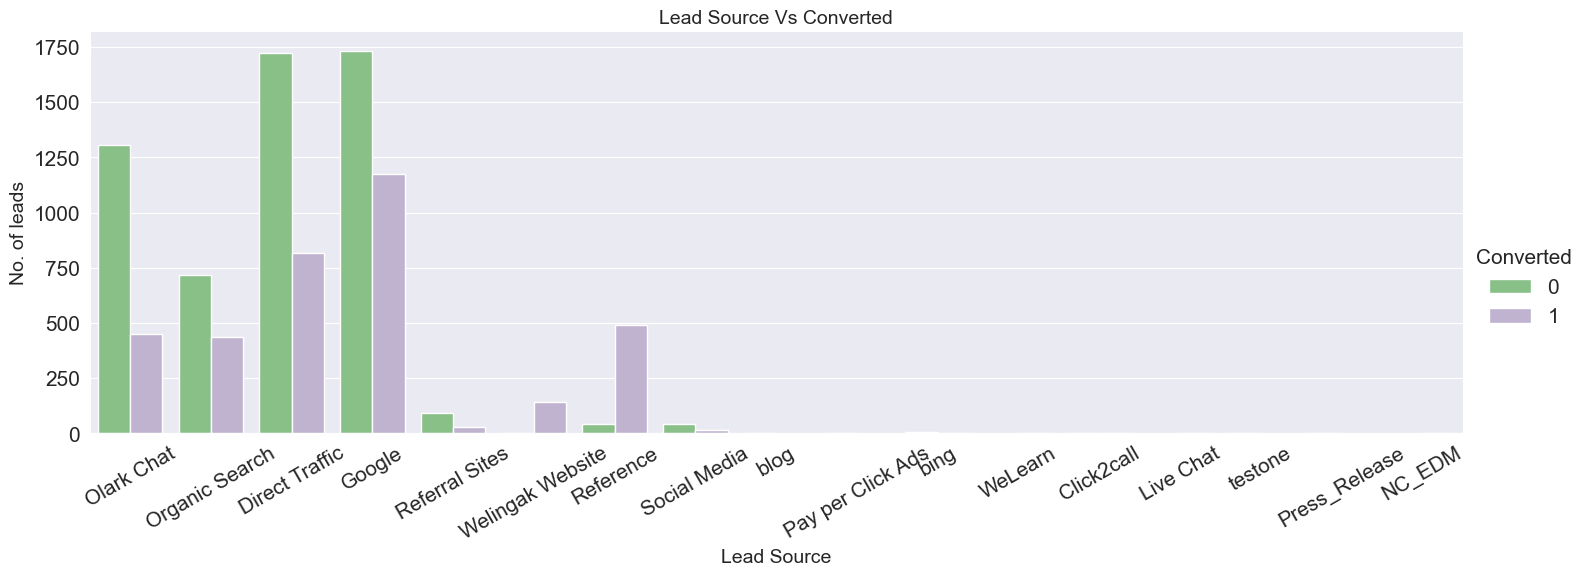

In [89]:
plot = sns.catplot(x="Lead Source", hue = "Converted", kind="count", data=leads, palette="Accent", aspect = 3);
plt.title('Lead Source Vs Converted', fontsize = 14)
plt.xlabel("Lead Source", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads come from google

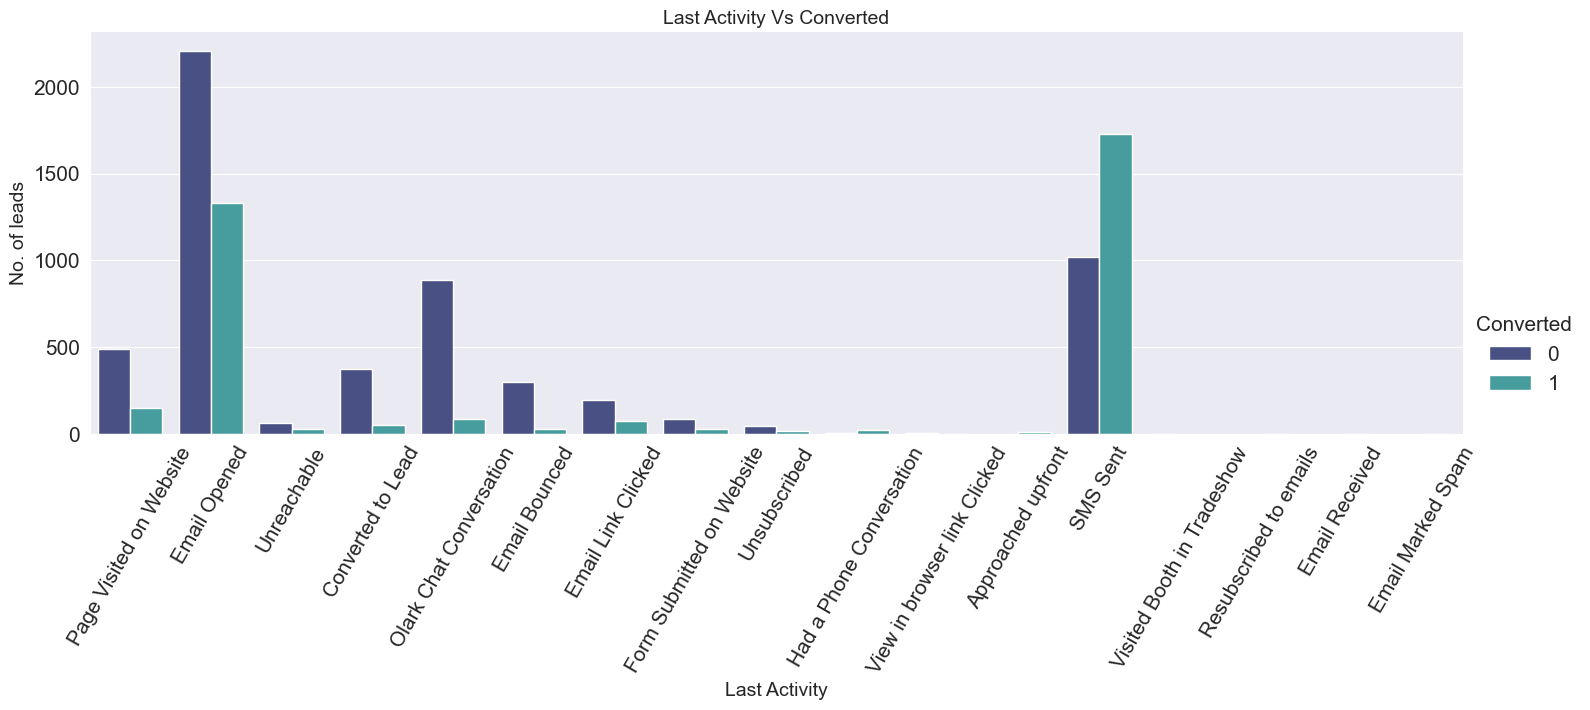

In [91]:
plot = sns.catplot(x="Last Activity", hue = "Converted", kind="count", data=leads, palette="mako", aspect = 3);
plt.title('Last Activity Vs Converted', fontsize = 14)
plt.xlabel("Last Activity", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=60)
plt.show()

most converted leads in category where last activity was 'sms sent'

Certain columns contain 'Unknown' as an entry. In the visualizations, they won't be accounted for as they don't provide any actionable insight.

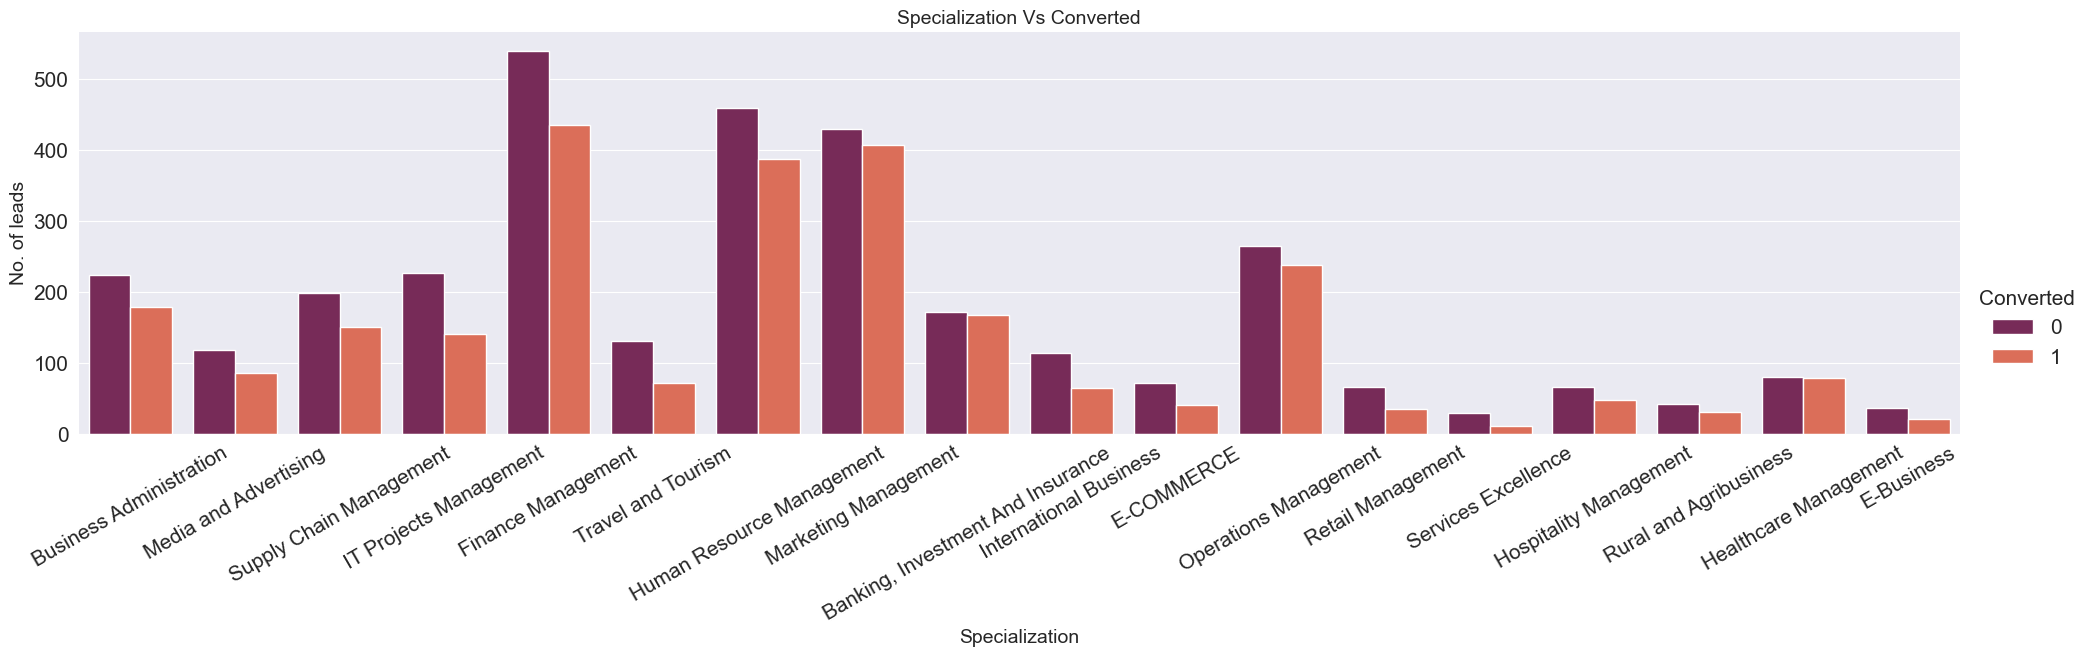

In [94]:
plot = sns.catplot(x="Specialization", hue = "Converted", kind="count", data=leads[leads['Specialization']!="Unknown"], palette="rocket", aspect = 4);
plt.title('Specialization Vs Converted', fontsize = 14)
plt.xlabel("Specialization", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads are from IT projects management

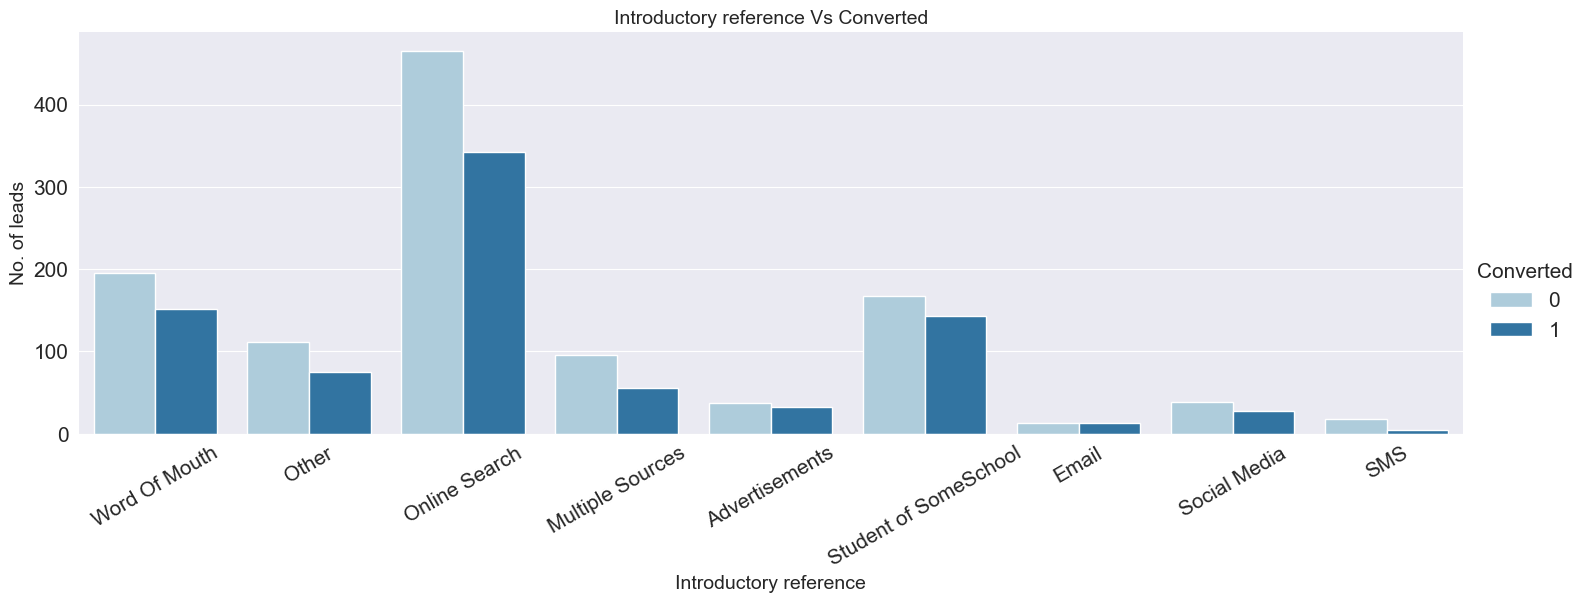

In [96]:
plot = sns.catplot(x="How did you hear about X Education", hue = "Converted", kind="count", data=leads[leads["How did you hear about X Education"]!="Unknown"], palette="Paired", aspect = 3);
plt.title('Introductory reference Vs Converted', fontsize = 14)
plt.xlabel("Introductory reference", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads are from online search

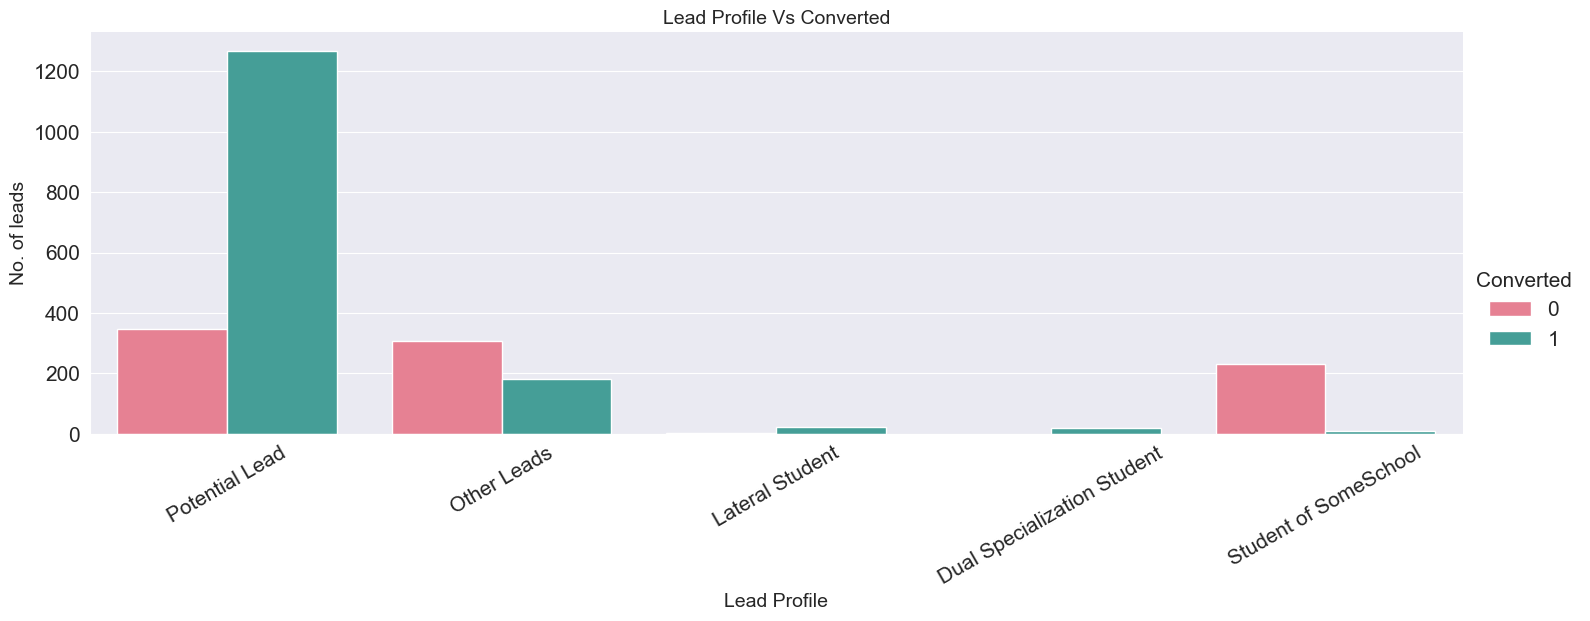

In [98]:
plot = sns.catplot(x="Lead Profile", hue = "Converted", kind="count", data=leads[leads["Lead Profile"]!="Unknown"], palette="husl", aspect = 3);
plt.title('Lead Profile Vs Converted', fontsize = 14)
plt.xlabel("Lead Profile", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads have a profile of 'potential lead'

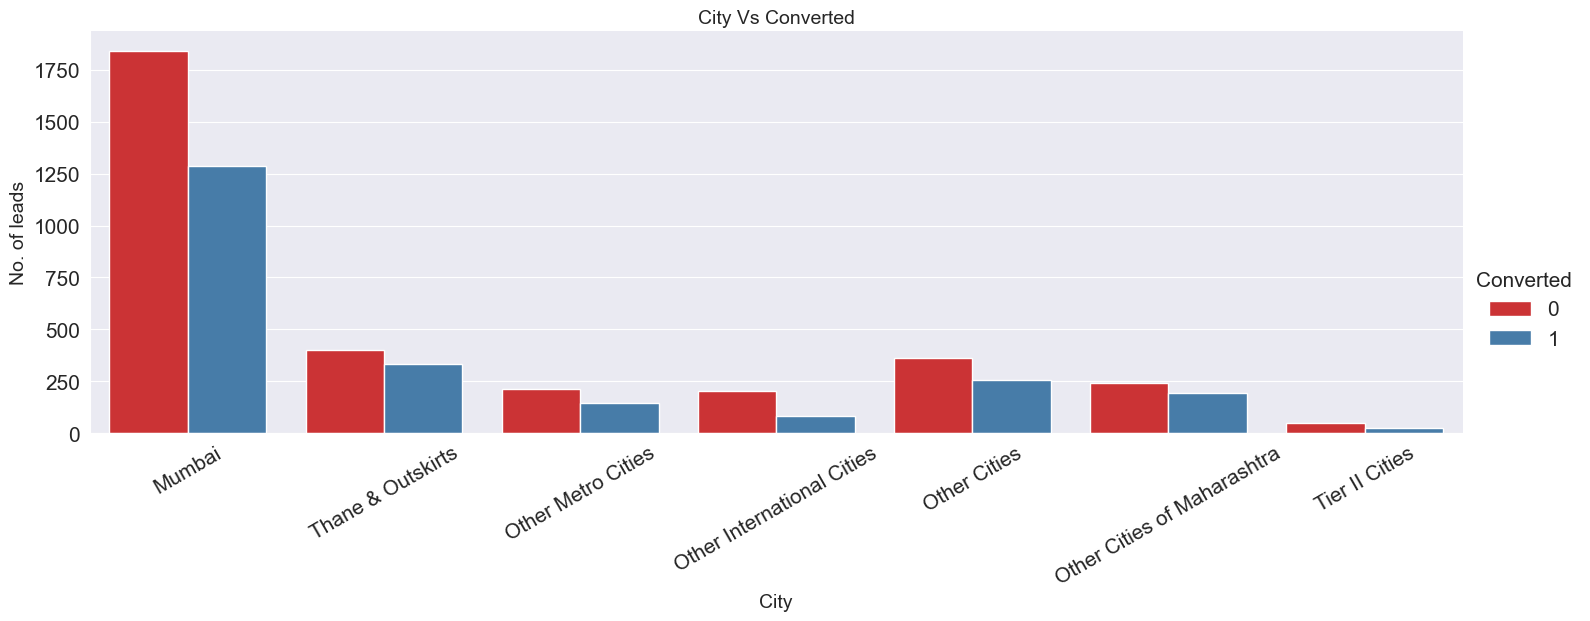

In [100]:
plot = sns.catplot(x="City", hue = "Converted", kind="count", data=leads[leads["City"]!="Unknown"], palette="Set1", aspect = 3);
plt.title('City Vs Converted', fontsize = 14)
plt.xlabel("City", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads are from Mumbai

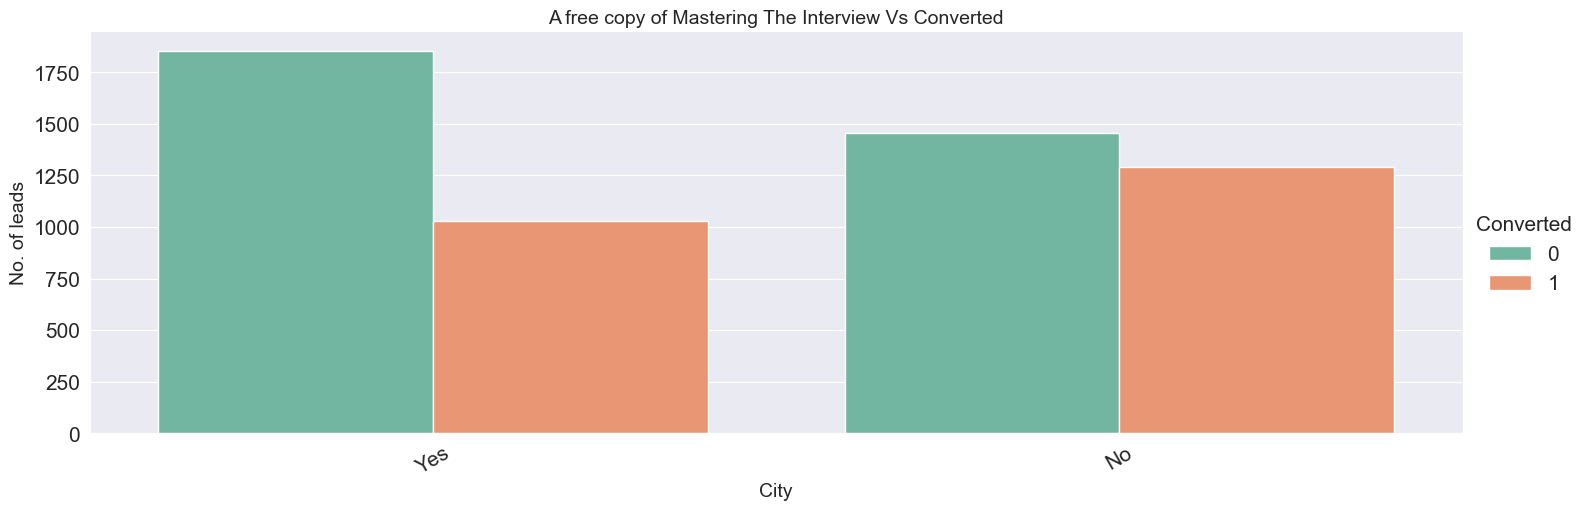

In [102]:
plot = sns.catplot(x="A free copy of Mastering The Interview", hue = "Converted", kind="count", data=leads[leads["City"]!="Unknown"], palette="Set2", aspect = 3);
plt.title('A free copy of Mastering The Interview Vs Converted', fontsize = 14)
plt.xlabel("City", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

People not taking the free book are more likely to convert than those who've taken the free book.

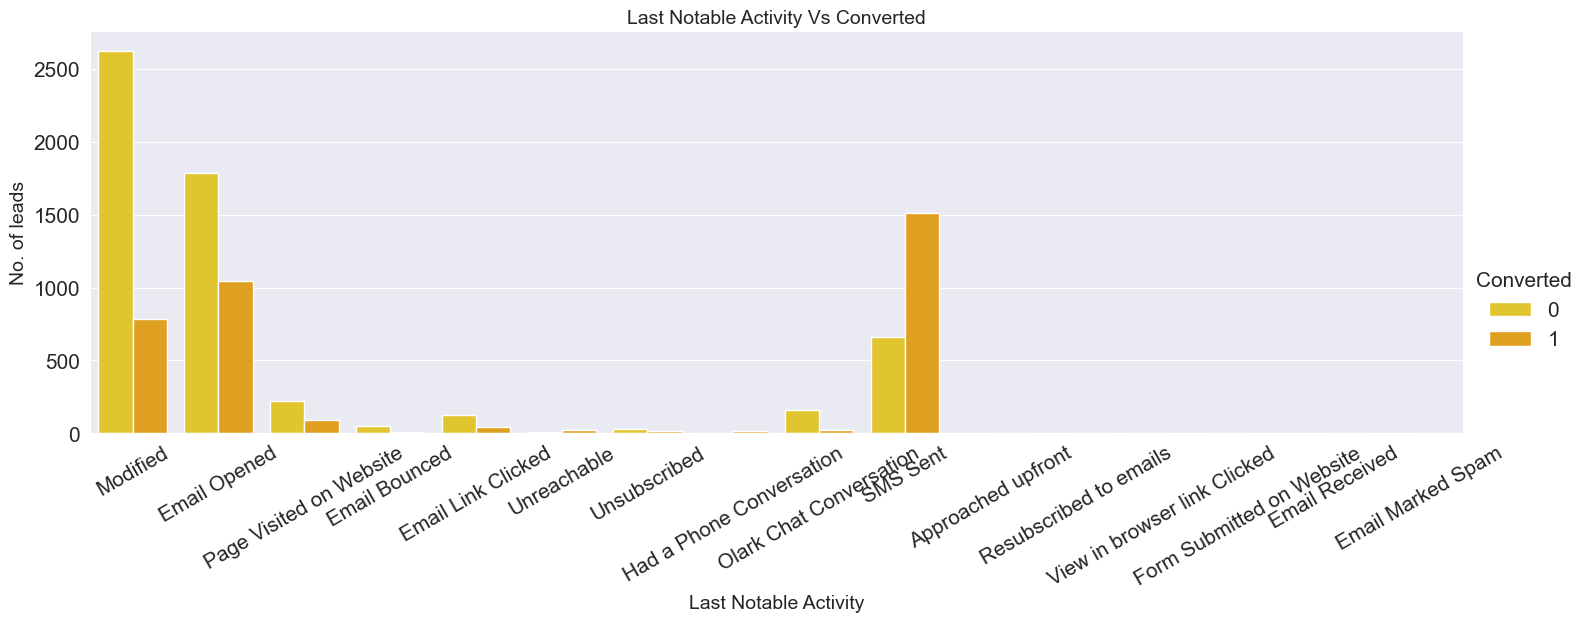

In [104]:
plot = sns.catplot(x="Last Notable Activity", hue = "Converted", kind="count", data=leads, palette="Wistia", aspect = 3);
plt.title('Last Notable Activity Vs Converted', fontsize = 14)
plt.xlabel("Last Notable Activity", fontsize = 14)
plt.ylabel("No. of leads", fontsize = 14)
plt.xticks(rotation=30)
plt.show()

most converted leads have last notable activity as 'modified'

### Outlier Analysis

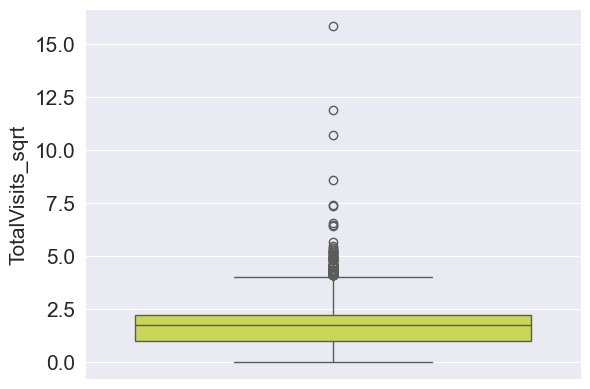

In [107]:
#checking the spread of the numerical variables.
sns.boxplot(leads['TotalVisits_sqrt'],color=randomcolor())
plt.show()

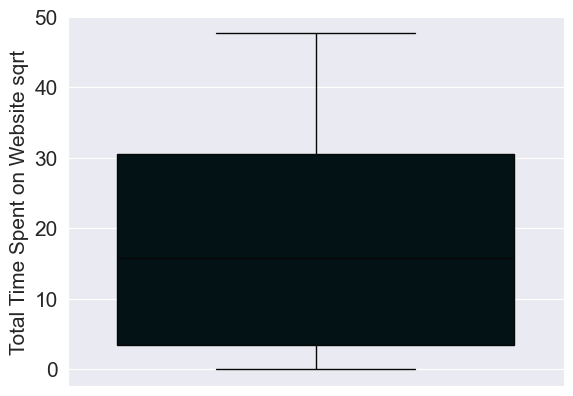

In [108]:
sns.boxplot(leads['Total Time Spent on Website sqrt'],color=randomcolor())
plt.show()

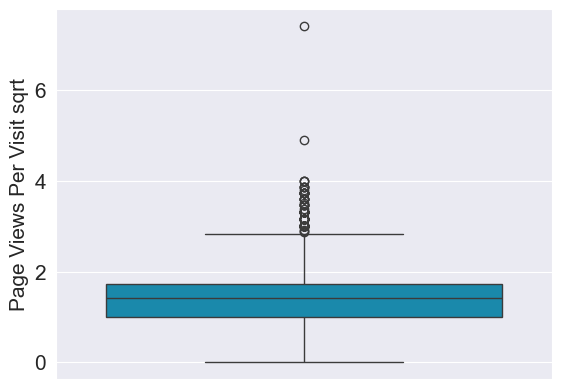

In [109]:
sns.boxplot(leads['Page Views Per Visit sqrt'],color=randomcolor())
plt.show()

In [110]:
leads.shape

(9240, 15)

Since we reduced the skewness as much as possible, we can go with the assumption of normally distributed data much more safely now. 
In a normal distribution, 99.7% of the data is contained within +-3 SD of the mean. We can use this to cut down on outliers.

In [112]:
out_num_leads=leads[['Page Views Per Visit sqrt','TotalVisits_sqrt']]
other_leads = pd.concat([leads.select_dtypes(include=['object']),leads['Total Time Spent on Website sqrt']],axis =1)
other_leads = pd.concat([other_leads,leads["Lead Number"],leads['Converted']],axis = 1)
q = out_num_leads.quantile(0.997)
out_num_leads = out_num_leads[out_num_leads < q]
out_num_leads.isnull().sum()

Page Views Per Visit sqrt    31
TotalVisits_sqrt             32
dtype: int64

Filling in missing values left by outliers by median.

In [114]:
out_num_leads['Page Views Per Visit sqrt'].fillna(out_num_leads['Page Views Per Visit sqrt'].median(), inplace=True)
out_num_leads['TotalVisits_sqrt'].fillna(out_num_leads['TotalVisits_sqrt'].median(), inplace=True)

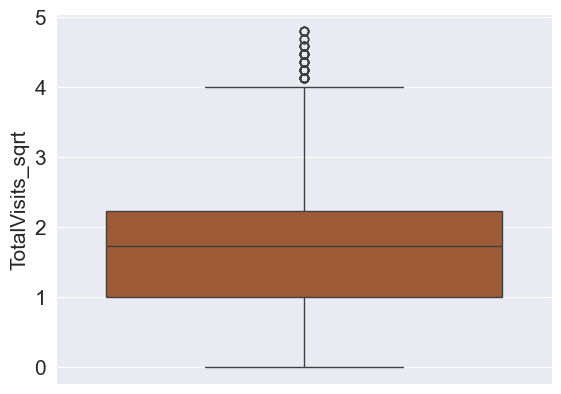

In [115]:
sns.boxplot(out_num_leads['TotalVisits_sqrt'],color=randomcolor())
plt.show()

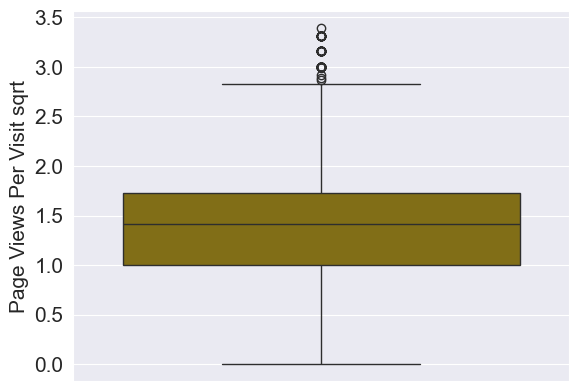

In [116]:
sns.boxplot(out_num_leads['Page Views Per Visit sqrt'],color=randomcolor())
plt.show()

One iteration of the process didn't remove as many outlying points as expected. We'll have 1 more iteration.

In [118]:
q = out_num_leads.quantile(0.997)
out_num_leads = out_num_leads[out_num_leads < q]
out_num_leads.isnull().sum()

Page Views Per Visit sqrt    44
TotalVisits_sqrt             36
dtype: int64

Filling in missing values left by outliers by median as outliers are still there.

In [120]:
out_num_leads['Page Views Per Visit sqrt'].fillna(out_num_leads['Page Views Per Visit sqrt'].median(), inplace=True)
out_num_leads['TotalVisits_sqrt'].fillna(out_num_leads['TotalVisits_sqrt'].median(), inplace=True)

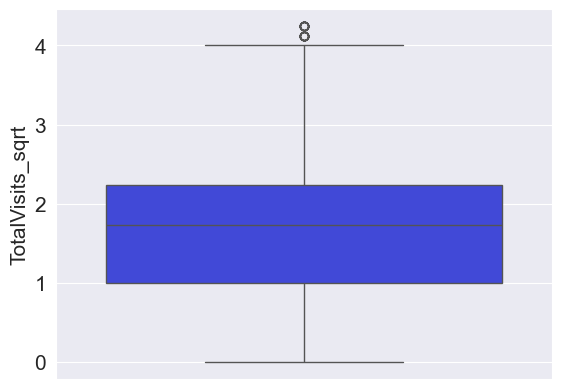

In [121]:
sns.boxplot(out_num_leads['TotalVisits_sqrt'],color=randomcolor())
plt.show()

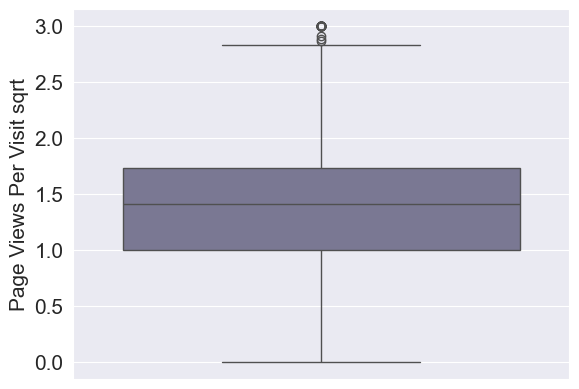

In [122]:
sns.boxplot(out_num_leads['Page Views Per Visit sqrt'],color=randomcolor())
plt.show()

Since only a handful of outliers are left, we can proceed. We shouldn't do this process when a few outlying values are left since we risk losing non outlying values too.

In [124]:
# View the first 5 rows to understand the columns and data format
leads.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Converted,Last Activity,Specialization,How did you hear about X Education,Lead Profile,City,A free copy of Mastering The Interview,Last Notable Activity,Total Time Spent on Website sqrt,Page Views Per Visit sqrt,TotalVisits_sqrt
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,0,Page Visited on Website,Unknown,Unknown,Unknown,Unknown,No,Modified,0.000000,0.000000,0.000000
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,0,Email Opened,Unknown,Unknown,Unknown,Unknown,No,Email Opened,25.961510,1.581139,2.236068
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,1,Email Opened,Business Administration,Unknown,Potential Lead,Mumbai,Yes,Email Opened,39.140772,1.414214,1.414214
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,0,Unreachable,Media and Advertising,Word Of Mouth,Unknown,Mumbai,No,Modified,17.464249,1.000000,1.000000
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,1,Converted to Lead,Unknown,Other,Unknown,Mumbai,No,Modified,37.788887,1.000000,1.414214


In [125]:
# Merge out_num_leads (numerical, outlier-treated) with other_leads (categorical + target)
# Reset index so that concat works correctly
out_num_leads = out_num_leads.reset_index(drop=True)
other_leads   = other_leads.reset_index(drop=True)
cleaned_leads = pd.concat([other_leads, out_num_leads], axis=1)
print('cleaned_leads shape:', cleaned_leads.shape)  # Confirm merge result

# Print dataset info – dtypes, null counts, and memory usage
cleaned_leads.info()

cleaned_leads shape: (9240, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Prospect ID                             9240 non-null   object 
 1   Lead Origin                             9240 non-null   object 
 2   Lead Source                             9240 non-null   object 
 3   Last Activity                           9240 non-null   object 
 4   Specialization                          9240 non-null   object 
 5   How did you hear about X Education      9240 non-null   object 
 6   Lead Profile                            9240 non-null   object 
 7   City                                    9240 non-null   object 
 8   A free copy of Mastering The Interview  9240 non-null   object 
 9   Last Notable Activity                   9240 non-null   object 
 10  Total Time Spent on Website 

### Data Preparation

#### encoding

In [128]:
# Import sklearn for One-Hot Encoding
# Categorical variables must be converted into binary dummy variables
from sklearn.preprocessing import OneHotEncoder

In [129]:
# Select all categorical columns, excluding Prospect ID (unique identifier)
# Only columns with 'object' dtype need to be dummy encoded
dummies_needed = cleaned_leads.drop('Prospect ID', axis=1).select_dtypes(include=['object'])
dummies_needed.columns

Index(['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization',
       'How did you hear about X Education', 'Lead Profile', 'City',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [130]:
# Use pd.get_dummies() to create binary columns for each categorical column
# e.g. 'City_Mumbai', 'City_Delhi', etc.
dummy = pd.get_dummies(dummies_needed)
dummy.head()

,Lead Origin_API,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Click2call,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Live Chat,Lead Source_NC_EDM,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,True,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


In [131]:
# Append dummy columns to cleaned_leads
# Then delete original categorical columns to avoid duplicates
cleaned_leads_dummified = pd.concat([cleaned_leads, dummy], axis=1)
for x in dummies_needed.columns:
    del cleaned_leads_dummified[x]
cleaned_leads_dummified.head()

,Prospect ID,Total Time Spent on Website sqrt,Lead Number,Converted,Page Views Per Visit sqrt,TotalVisits_sqrt,Lead Origin_API,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,0.000000,660737,0,0.000000,0.000000,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2a272436-5132-4136-86fa-dcc88c88f482,25.961510,660728,0,1.581139,2.236068,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,39.140772,660727,1,1.414214,1.414214,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,17.464249,660719,0,1.000000,1.000000,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,3256f628-e534-4826-9d63-4a8b88782852,37.788887,660681,1,1.000000,1.414214,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


### test train split, standardization

In [133]:
# Import required libraries for model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [134]:
# Prospect ID plays no role in model training, so drop it
# Target variable Y = 'Converted' (1 = lead converted, 0 = not converted)
# Feature matrix X = all remaining columns
cleaned_leads_dummified_final = cleaned_leads_dummified.drop('Prospect ID', axis=1)
Y = cleaned_leads_dummified_final.Converted
X = cleaned_leads_dummified_final.drop('Converted', axis=1)

In [135]:
# Split data into 70% training and 30% testing sets
# random_state=42 ensures reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [136]:
# Standardize features using StandardScaler (mean=0, std=1)
# First fill any remaining NaN values using SimpleImputer
# (Some NaN values may remain after outlier removal)
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy='median')   # Replace NaN with median
sc  = StandardScaler()                    # Z-score normalization

# Lead Number is an identifier and is not useful for model training
X_train_no_lead = X_train.drop('Lead Number', axis=1)
X_test_no_lead  = X_test.drop('Lead Number', axis=1)

# fit_transform: fit and transform on training data
# transform: apply only on test data to prevent data leakage
X_train_imputed = imp.fit_transform(X_train_no_lead)
X_test_imputed  = imp.transform(X_test_no_lead)
X_train_std = sc.fit_transform(X_train_imputed)
X_test_std  = sc.transform(X_test_imputed)

In [137]:
X_train_std

array([[-1.24357164, -1.59171528, -1.5213129 , ..., -0.06229109,
        -0.06352963, -0.01243508],
       [ 1.31102782, -0.34587912, -0.09566514, ..., -0.06229109,
        -0.06352963, -0.01243508],
       [ 0.17898971, -0.15494693,  0.4948575 , ..., -0.06229109,
        -0.06352963, -0.01243508],
       ...,
       [-1.24357164, -1.59171528, -1.5213129 , ..., -0.06229109,
        -0.06352963, -0.01243508],
       [-0.27609154,  0.56613624,  0.22474188, ..., -0.06229109,
        -0.06352963, -0.01243508],
       [ 1.83206345, -0.34587912, -0.09566514, ..., -0.06229109,
        -0.06352963, -0.01243508]])

### Feature Importances, Initial Modeling

In [139]:
# Logistic Regression model import karo
# Binary classification ke liye sabse suitable algorithm hai
from sklearn.linear_model import LogisticRegression

In [140]:
# ── Feature Importance Model ─────────────────────────────────────
# Fit Logistic Regression on standardized data
# liblinear solver – efficient for small to medium datasets
logit_model = LogisticRegression(solver='liblinear')
logit_model.fit(X_train_std, Y_train)

# Model coefficients represent feature importance
# Positive coeff → conversion probability badhata hai
# Negative coeff → conversion probability ghatata hai
feature = pd.DataFrame()
feature['column']     = X_train.drop('Lead Number', axis=1).columns
feature['importance'] = logit_model.coef_[0]
feature.sort_values('importance', ascending=False, inplace=True)
feature

,column,importance
0,Total Time Spent on Website sqrt,1.287743
5,Lead Origin_Lead Add Form,0.678704
21,Lead Source_Welingak Website,0.644231
74,Lead Profile_Potential Lead,0.467232
99,Last Notable Activity_SMS Sent,0.391937
...,...,...
4,Lead Origin_Landing Page Submission,-0.301639
76,Lead Profile_Unknown,-0.301848
27,Last Activity_Email Bounced,-0.337800
75,Lead Profile_Student of SomeSchool,-0.427370


Features having positive influence on the model are stated below

In [142]:
feature[feature["importance"]>0]

,column,importance
0,Total Time Spent on Website sqrt,1.287743
5,Lead Origin_Lead Add Form,0.678704
21,Lead Source_Welingak Website,0.644231
74,Lead Profile_Potential Lead,0.467232
99,Last Notable Activity_SMS Sent,0.391937
71,Lead Profile_Dual Specialization Student,0.337151
37,Last Activity_SMS Sent,0.293863
13,Lead Source_Olark Chat,0.292450
25,Last Activity_Approached upfront,0.284505
2,TotalVisits_sqrt,0.260556


Redundant Features-

In [144]:
feature[feature["importance"]==0]

,column,importance
16,Lead Source_Press_Release,0.0
93,Last Notable Activity_Form Submitted on Website,0.0
24,Lead Source_testone,0.0
36,Last Activity_Resubscribed to emails,0.0
98,Last Notable Activity_Resubscribed to emails,0.0


Features having negative effect on model performance-

In [146]:
feature[feature["importance"]<0]

,column,importance
64,How did you hear about X Education_Online Search,-0.002049
57,Specialization_Services Excellence,-0.003678
69,How did you hear about X Education_Unknown,-0.008193
65,How did you hear about X Education_Other,-0.010262
81,City_Other Metro Cities,-0.012233
77,City_Mumbai,-0.015244
80,City_Other International Cities,-0.017059
18,Lead Source_Referral Sites,-0.018421
32,Last Activity_Form Submitted on Website,-0.029092
61,How did you hear about X Education_Advertisements,-0.030692


#### Feature Importance – Visual Overview

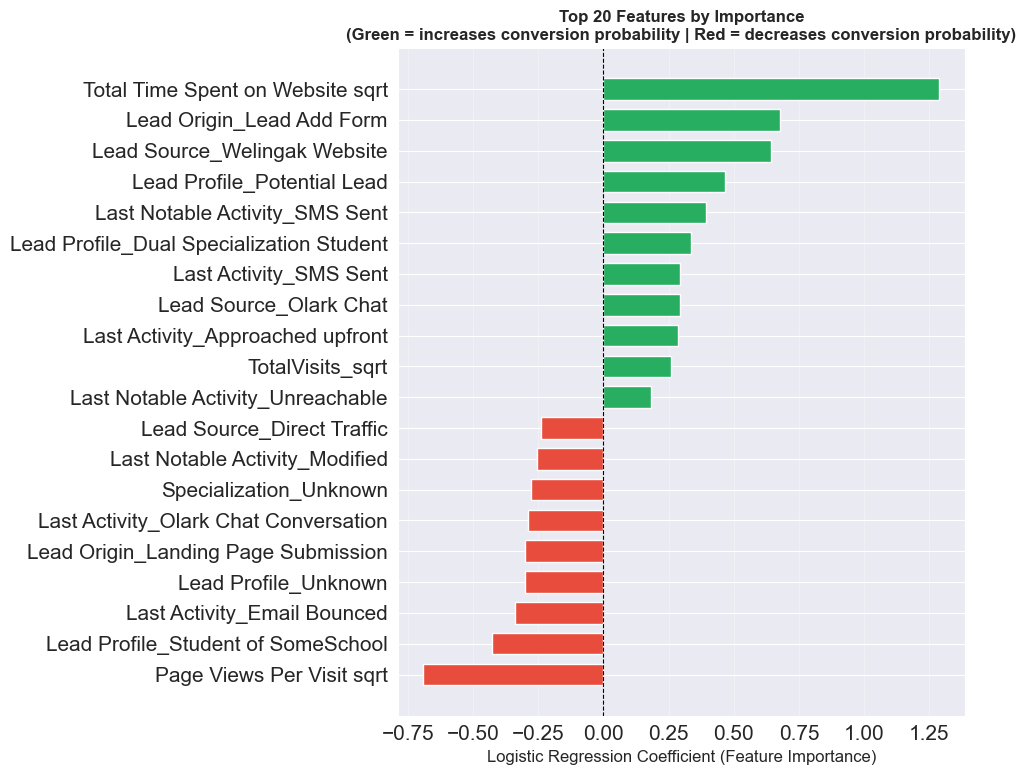

In [148]:
# ── Feature Importance Bar Chart ────────────────────────────────────────────
# Visualize which features most strongly influence lead conversion
# Green = positive impact (increases conversion), Red = negative impact

top_n = 20  # Show top N features by absolute importance
feat_plot = feature.copy()
feat_plot = feat_plot.reindex(feat_plot['importance'].abs().sort_values(ascending=False).index)
feat_plot = feat_plot.head(top_n).sort_values('importance')

colors = ['#e74c3c' if v < 0 else '#27ae60' for v in feat_plot['importance']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_plot['column'], feat_plot['importance'], color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Logistic Regression Coefficient (Feature Importance)', fontsize=12)
ax.set_title(
    f'Top {top_n} Features by Importance\n'
    '(Green = increases conversion probability | Red = decreases conversion probability)',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Model Evaluation

In [150]:
# Import metrics for model evaluation
from sklearn.metrics import (
    accuracy_score, mean_absolute_error, mean_squared_error,
    median_absolute_error, confusion_matrix,
    f1_score, recall_score, precision_score
)

In [151]:
# ── Baseline Model (Model 1) ──────────────────────────────────────
# Train Logistic Regression on imputed (NaN-free) training data
# This is the baseline model — prior to feature selection
Logit = LogisticRegression(solver='liblinear')

# Create imputed DataFrames while preserving the original index
X_train_imp_df = pd.DataFrame(
    X_train_imputed, index=X_train.index, columns=X_train_no_lead.columns)
X_test_imp_df  = pd.DataFrame(
    X_test_imputed,  index=X_test.index,  columns=X_test_no_lead.columns)

Logit.fit(X_train_imp_df, Y_train)

print('Score the X-train with Y-train is :', str(round(Logit.score(X_train_imp_df, Y_train)*100, 2)), '%')
print('Score the X-test  with Y-test  is :', str(round(Logit.score(X_test_imp_df,  Y_test )*100, 2)), '%')

Y_pred = Logit.predict(X_test_imp_df)

print(' Mean absolute error is ',   mean_absolute_error(Y_test, Y_pred))
print(' Mean squared  error is ',   mean_squared_error(Y_test, Y_pred))
print(' Median absolute error is ', median_absolute_error(Y_test, Y_pred))
print('Accuracy is ', round(accuracy_score(Y_test, Y_pred)*100, 2), '%')

Score the X-train with Y-train is : 82.39 %
Score the X-test  with Y-test  is : 83.01 %
 Mean absolute error is  0.1699134199134199
 Mean squared  error is  0.1699134199134199
 Median absolute error is  0.0
Accuracy is  83.01 %


### Fine Tuning the model
creating new test & train variables by using the insights from feature selection

In [153]:
# Retain only features with positive importance
# Negative/zero importance features degrade model performance
X_train_new = X_train_imp_df[[x for x in feature[feature['importance'] > 0].column]]
X_test_new  = X_test_imp_df[ [x for x in feature[feature['importance'] > 0].column]]

checking p values & variance inflation factor

In [155]:
# Install compatible versions of statsmodels and scipy
# Required for GLM (Generalized Linear Model) and VIF calculations
!pip install scipy==1.13.1 statsmodels==0.14.2 -q

In [156]:
# Verify that the correct scipy version is installed
import scipy
print('scipy version:', scipy.__version__)

scipy version: 1.13.1


In [157]:
# statsmodels: for GLM and statistical testing
import statsmodels.api as sm

In [158]:
# Add a constant (intercept) column for GLM
# Binomial family = logistic regression (binary outcome)
X_train_sm = sm.add_constant(X_train_new)
logm = sm.GLM(Y_train, X_train_sm, family=sm.families.Binomial())
res  = logm.fit()

# Summary contains p-values, confidence intervals, and z-scores
# Features with p-value < 0.05 are statistically significant
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6414
Model Family:                Binomial   Df Model:                           53
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2634.3
Date:                Sun, 12 Jul 2026   Deviance:                       5268.6
Time:                        23:32:14   Pearson chi2:                 6.73e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.4040
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
const                                                       -5.2357      0.212    -24.717      0.000      -5.651      -4.821
Total Time Spent on Website sqrt                             0.0913      0.004     25.882      0.000       0.084       0.098
Lead Origin_Lead Add Form                                    3.8037      0.233     16.335      0.000       3.347       4.260
Lead Source_Welingak Website                                24.3569    2.2e+04      0.001      0.999   -4.32e+04    4.32e+04
Lead Profile_Potential Lead                                  2.0541      0.100     20.617      0.000       1.859       2.249
Last Notable Activity_SMS Sent                               1.4208      0.147      9.656      0.000       1.132       1.709
Lead Profile_Dual Specialization Student                    25.8613   4.96e+04      0.001      1.000   -9.72e+04    9.73e+04
Last Activity_SMS Sent                                       1.1655      0.154      7.564      0.000       0.864       1.468
Lead Source_Olark Chat                                       1.8496      0.155     11.895      0.000       1.545       2.154
Last Activity_Approached upfront                            26.4927   5.85e+04      0.000      1.000   -1.15e+05    1.15e+05
TotalVisits_sqrt                                             0.0608      0.060      1.020      0.308      -0.056       0.178
Last Notable Activity_Unreachable                            3.0678      0.548      5.600      0.000       1.994       4.142
Last Activity_Email Opened                                   1.0067      0.096     10.514      0.000       0.819       1.194
Last Notable Activity_Unsubscribed                           1.1005      0.516      2.131      0.033       0.089       2.113
Last Notable Activity_Had a Phone Conversation               3.0938      1.379      2.243      0.025       0.391       5.797
Specialization_Marketing Management                          0.6963      0.155      4.480      0.000       0.392       1.001
Last Notable Activity_Email Bounced                          0.4762      0.451      1.057      0.291      -0.407       1.359
Lead Profile_Lateral Student                                 2.6705      1.086      2.458      0.014       0.541       4.800
Lead Source_Live Chat                                       23.6732   1.53e+05      0.000      1.000   -2.99e+05    2.99e+05
Specialization_Banking, Investment And Insurance             0.6762      0.208      3.252      0.001       0.269       1.084
Lead Source_NC_EDM                                          26.2188   2.16e+05      0.000      1.000   -4.23e+05    4.23e+05
Specialization_Finance Management                            0.5763      0.157     

In [159]:
# VIF (Variance Inflation Factor) – to detect multicollinearity
# VIF > 5 indicates high correlation between that feature and other features
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [160]:
# Calculate VIF for each feature
# VIF <= 5: acceptable (low multicollinearity)
# VIF > 5: remove the feature (highly correlated with others)
vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_new.values, i)
    for i in range(X_train_new.shape[1])
]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by='VIF', ascending=False)
vif

,Features,VIF
27,Last Notable Activity_Email Received,inf
32,Last Notable Activity_Email Marked Spam,inf
31,Last Activity_Email Marked Spam,inf
28,Last Activity_Email Received,inf
9,TotalVisits_sqrt,6.77
6,Last Activity_SMS Sent,5.77
36,A free copy of Mastering The Interview_No,4.90
4,Last Notable Activity_SMS Sent,4.72
42,City_Unknown,4.46
0,Total Time Spent on Website sqrt,4.32


### Final model

In [162]:
# Retain only features with VIF <= 5 in the final model
# This eliminates multicollinearity and stabilizes the model
x_train_vif_adj = X_train_new[[x for x in list(vif[vif['VIF'] <= 5]['Features'])]]
x_test_vif_adj  = X_test_new[ [x for x in list(vif[vif['VIF'] <= 5]['Features'])]]

In [163]:
# ── Final Model (VIF-adjusted features) ──────────────────────────
# Train model on the reduced feature set
Logit = LogisticRegression(solver='liblinear')
Logit.fit(x_train_vif_adj, Y_train)

print('Score the X-train with Y-train is :', str(round(Logit.score(x_train_vif_adj, Y_train)*100, 2)), '%')
print('Score the X-test  with Y-test  is :', str(round(Logit.score(x_test_vif_adj,  Y_test )*100, 2)), '%')

Y_pred = Logit.predict(x_test_vif_adj)

print(' Mean absolute error is ',   mean_absolute_error(Y_test, Y_pred))
print(' Mean squared  error is ',   mean_squared_error(Y_test, Y_pred))
print(' Median absolute error is ', median_absolute_error(Y_test, Y_pred))
print('Accuracy is ', round(accuracy_score(Y_test, Y_pred)*100, 2), '%')

Score the X-train with Y-train is : 80.81 %
Score the X-test  with Y-test  is : 81.93 %
 Mean absolute error is  0.18073593073593072
 Mean squared  error is  0.18073593073593072
 Median absolute error is  0.0
Accuracy is  81.93 %


### Measuring Model Performance

In [165]:
# Extract detailed performance metrics from the Confusion Matrix
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

precision = precision_score(Y_test, Y_pred)
recall    = recall_score(Y_test, Y_pred)
f1        = f1_score(Y_test, Y_pred)
fpr       = fp / float(tn + fp)   # False Positive Rate
fnr       = fn / float(tp + fn)   # False Negative Rate

print('Sensitivity (True Positive Rate):', recall)
print('False Positive Rate:',              fpr)
print('Specificity (True Negative Rate):', tn/(tn+fp))
print('False Negative Rate:',              fnr)
print('Precision:',                        precision)
print('F-Score:',                          f1)

Sensitivity (True Positive Rate): 0.7019498607242339
False Positive Rate: 0.10619469026548672
Specificity (True Negative Rate): 0.8938053097345132
False Negative Rate: 0.298050139275766
Precision: 0.8076923076923077
F-Score: 0.7511177347242921


#### Confusion Matrix Heatmap

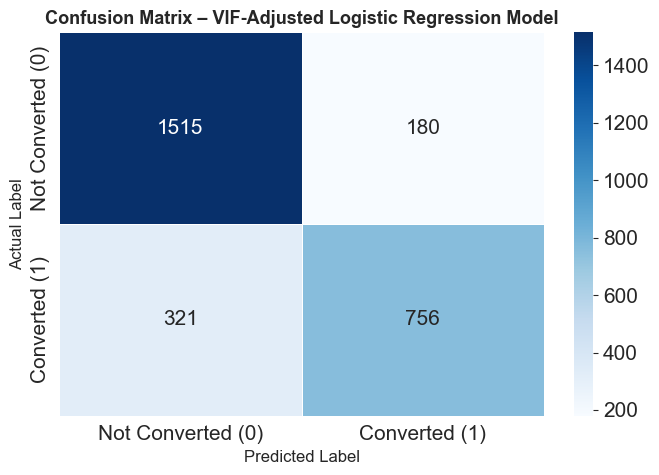

True  Negatives  (TN): 1515  (54.7%)
False Positives  (FP):  180  (6.5%)
False Negatives  (FN):  321  (11.6%)
True  Positives  (TP):  756  (27.3%)


In [167]:
# ── Confusion Matrix Visualization ─────────────────────────────────────────
# A heatmap makes it easier to interpret True/False Positives and Negatives
import numpy as np

cm_array = confusion_matrix(Y_test, Y_pred)
cm_labels = ['Not Converted (0)', 'Converted (1)']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_array,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_title('Confusion Matrix – VIF-Adjusted Logistic Regression Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print percentage breakdown
total = cm_array.sum()
print(f'True  Negatives  (TN): {cm_array[0,0]:4d}  ({cm_array[0,0]/total*100:.1f}%)')
print(f'False Positives  (FP): {cm_array[0,1]:4d}  ({cm_array[0,1]/total*100:.1f}%)')
print(f'False Negatives  (FN): {cm_array[1,0]:4d}  ({cm_array[1,0]/total*100:.1f}%)')
print(f'True  Positives  (TP): {cm_array[1,1]:4d}  ({cm_array[1,1]/total*100:.1f}%)')


### Refitting GLM with new set of features

In [169]:
# Refit GLM using VIF-adjusted features
# This is the final statistical model with reliable coefficients
X_train_vif_sm = sm.add_constant(x_train_vif_adj)
logm1 = sm.GLM(Y_train, X_train_vif_sm, family=sm.families.Binomial())
res1  = logm1.fit()
res1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6418
Model Family:                Binomial   Df Model:                           49
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2663.9
Date:                Sun, 12 Jul 2026   Deviance:                       5327.8
Time:                        23:32:17   Pearson chi2:                 6.86e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.3985
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
const                                                       -4.8443      0.175    -27.679      0.000      -5.187      -4.501
A free copy of Mastering The Interview_No                    0.2911      0.094      3.107      0.002       0.108       0.475
Last Notable Activity_SMS Sent                               2.3008      0.096     23.987      0.000       2.113       2.489
City_Unknown                                                 0.4272      0.136      3.150      0.002       0.161       0.693
Total Time Spent on Website sqrt                             0.0920      0.003     26.485      0.000       0.085       0.099
Lead Source_Olark Chat                                       1.7159      0.129     13.262      0.000       1.462       1.970
Last Activity_Email Opened                                   0.7271      0.085      8.548      0.000       0.560       0.894
Last Activity_Had a Phone Conversation                       0.7369      0.840      0.877      0.380      -0.909       2.383
Lead Origin_Lead Add Form                                    3.8033      0.216     17.601      0.000       3.380       4.227
Last Notable Activity_Had a Phone Conversation               3.0887      1.378      2.242      0.025       0.388       5.789
Specialization_Finance Management                            0.5814      0.156      3.730      0.000       0.276       0.887
Specialization_Human Resource Management                     0.3579      0.157      2.279      0.023       0.050       0.666
Specialization_Marketing Management                          0.6943      0.154      4.505      0.000       0.392       0.996
Lead Profile_Potential Lead                                  2.0420      0.099     20.681      0.000       1.848       2.236
Specialization_Operations Management                         0.6580      0.182      3.625      0.000       0.302       1.014
Specialization_Business Administration                       0.4933      0.192      2.570      0.010       0.117       0.869
Specialization_Banking, Investment And Insurance             0.7071      0.206      3.432      0.001       0.303       1.111
Specialization_Supply Chain Management                       0.5542      0.209      2.649      0.008       0.144       0.964
Lead Source_Welingak Website                                24.4642   2.16e+04      0.001      0.999   -4.23e+04    4.24e+04
Specialization_IT Projects Management                        0.6262      0.208      3.017      0.003       0.219       1.033
Specialization_Travel and Tourism                            0.3902      0.256      1.525      0.127      -0.111       0.892
Specialization_Media and Advertising                         0.4456      0.253     

In [170]:
# Extract predicted probability values on the training set
# GLM predict() returns probabilities between 0 and 1 (not binary labels)
y_train_pred = res1.predict(X_train_vif_sm)

# Store results in a structured DataFrame
y_train_pred_final = pd.DataFrame({
    'Converted': Y_train.values,
    'Converted_Probabillity': y_train_pred
})
y_train_pred_final['LeadId'] = Y_train.index
y_train_pred_final.head()

,Converted,Converted_Probabillity,LeadId
4715,0,0.156707,4715
7132,1,0.593791,7132
8954,0,0.858255,8954
5283,0,0.204956,5283
3003,0,0.249268,3003


creating a new column "predicted" which is 1 if prob>0.5 else 0, 0.5 is arbitrarily selected.

In [172]:
# Probability > 0.5 → predicted = 1 (converted), warna 0
# 0.5 is an initial threshold; the optimal value will be determined later
y_train_pred_final['predicted'] = y_train_pred_final.Converted_Probabillity.map(
    lambda x: 1 if x > 0.5 else 0
)
y_train_pred_final.head()

,Converted,Converted_Probabillity,LeadId,predicted
4715,0,0.156707,4715,0
7132,1,0.593791,7132,1
8954,0,0.858255,8954,1
5283,0,0.204956,5283,0
3003,0,0.249268,3003,0


### ROC Curve


In [174]:
# Import metrics for ROC Curve and AUC score computation
from sklearn.metrics import auc, roc_curve, roc_auc_score

In [175]:
# Calculate False Positive Rate and True Positive Rate for the ROC curve
# drop_intermediate=False: retains all threshold data points
fpr, tpr, thresholds = roc_curve(
    y_train_pred_final.Converted,
    y_train_pred_final.Converted_Probabillity,
    drop_intermediate=False
)

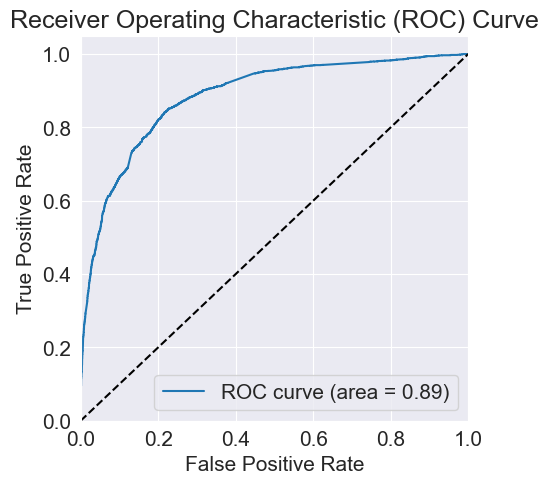

In [176]:
# Calculate AUC (Area Under Curve) and plot the ROC curve
# AUC = 1.0 → perfect model | AUC = 0.5 → random guessing
auc_score = roc_auc_score(
    y_train_pred_final.Converted,
    y_train_pred_final.Converted_Probabillity
)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], 'k--')   # Random classifier reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### Finding optimal cutoff pt for 'predicted' column, since 0.5 was chosen arbitrarily.

In [178]:
# Test different probability thresholds ranging from 0.0 to 0.9
# Create a binary prediction column for each threshold
nums = [float(x)/10 for x in range(10)]
for i in nums:
    y_train_pred_final[i] = y_train_pred_final.Converted_Probabillity.map(
        lambda x: 1 if x > i else 0
    )
y_train_pred_final.head()

,Converted,Converted_Probabillity,LeadId,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
4715,0,0.156707,4715,0,1,1,0,0,0,0,0,0,0,0
7132,1,0.593791,7132,1,1,1,1,1,1,1,0,0,0,0
8954,0,0.858255,8954,1,1,1,1,1,1,1,1,1,1,0
5283,0,0.204956,5283,0,1,1,1,0,0,0,0,0,0,0
3003,0,0.249268,3003,0,1,1,1,0,0,0,0,0,0,0


In [179]:
# Calculate accuracy, sensitivity, and specificity at each threshold
# Optimal cutoff is where sensitivity and specificity are balanced
probabillity_cutoff = pd.DataFrame(
    columns=['probabillity', 'accuracy', 'sensitivity', 'specificity']
)

nums = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for i in nums:
    cm    = confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i])
    total = sum(sum(cm))
    accuracy    = (cm[0,0] + cm[1,1]) / total
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])
    sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])
    probabillity_cutoff.loc[i] = [i, accuracy, sensitivity, specificity]

probabillity_cutoff

,probabillity,accuracy,sensitivity,specificity
0.0,0.0,0.384045,1.000000,0.000000
0.1,0.1,0.635591,0.965781,0.429719
0.2,0.2,0.762987,0.902576,0.675954
0.3,0.3,0.801020,0.851852,0.769327
0.4,0.4,0.809678,0.781401,0.827309
0.5,0.5,0.808287,0.671900,0.893323
0.6,0.6,0.806586,0.604267,0.932731
0.7,0.7,0.791280,0.542673,0.946285
0.8,0.8,0.768089,0.448068,0.967620
0.9,0.9,0.712894,0.268519,0.989960


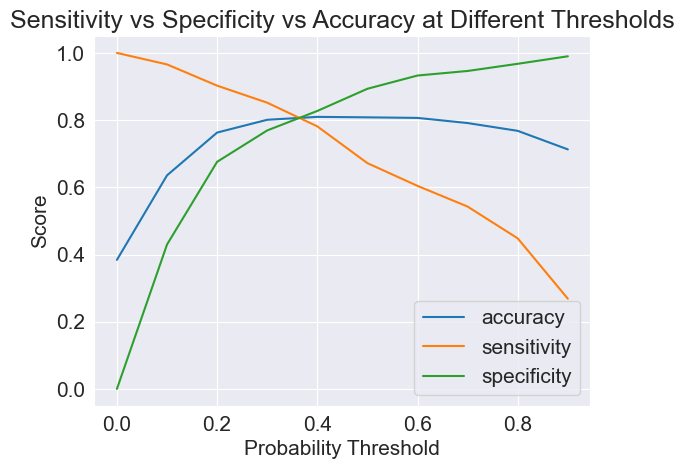

In [180]:
# Visually identify the optimal cutoff using a line plot
# Intersection point of sensitivity and specificity = best threshold
probabillity_cutoff.plot.line(
    x='probabillity',
    y=['accuracy', 'sensitivity', 'specificity']
)
plt.title('Sensitivity vs Specificity vs Accuracy at Different Thresholds')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.show()

we can see that the intersection point is somewhere between 0.35 and 0.4- assuming it to be the midpoint i.e. 0.375.

Now we'll modify the predicted variable accordingly.

In [182]:
# Optimal threshold = 0.375 (sensitivity-specificity intersection)
# Probability > 0.375 → lead likely to convert (predicted = 1)
y_train_pred_final['predicted'] = y_train_pred_final.Converted_Probabillity.map(
    lambda x: 1 if x > 0.375 else 0
)
y_train_pred_final.head()

,Converted,Converted_Probabillity,LeadId,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
4715,0,0.156707,4715,0,1,1,0,0,0,0,0,0,0,0
7132,1,0.593791,7132,1,1,1,1,1,1,1,0,0,0,0
8954,0,0.858255,8954,1,1,1,1,1,1,1,1,1,1,0
5283,0,0.204956,5283,0,1,1,1,0,0,0,0,0,0,0
3003,0,0.249268,3003,0,1,1,1,0,0,0,0,0,0,0


In [183]:
# Lead Score = conversion probability * 100
# Score on a 0-100 scale: higher score = higher conversion likelihood
y_train_pred_final['Score'] = y_train_pred_final.Converted_Probabillity.map(
    lambda x: round(x * 100)
)
y_train_pred_final

,Converted,Converted_Probabillity,LeadId,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,Score
4715,0,0.156707,4715,0,1,1,0,0,0,0,0,0,0,0,16
7132,1,0.593791,7132,1,1,1,1,1,1,1,0,0,0,0,59
8954,0,0.858255,8954,1,1,1,1,1,1,1,1,1,1,0,86
5283,0,0.204956,5283,0,1,1,1,0,0,0,0,0,0,0,20
3003,0,0.249268,3003,0,1,1,1,0,0,0,0,0,0,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0,0.081687,5734,0,1,0,0,0,0,0,0,0,0,0,8
5191,0,0.082408,5191,0,1,0,0,0,0,0,0,0,0,0,8
5390,1,0.981123,5390,1,1,1,1,1,1,1,1,1,1,1,98
860,0,0.126343,860,0,1,1,0,0,0,0,0,0,0,0,13


---
## Model Comparison
Comparing the Baseline model (all features) against the Final VIF-adjusted model.


In [185]:
# ── Model Comparison Summary ────────────────────────────────────────────────
# Side-by-side comparison of Baseline vs Final (VIF-adjusted) model metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Baseline model predictions (X_test_imp_df)
baseline_model = LogisticRegression(solver='liblinear')
baseline_model.fit(X_train_imp_df, Y_train)
y_pred_baseline = baseline_model.predict(X_test_imp_df)
y_prob_baseline = baseline_model.predict_proba(X_test_imp_df)[:, 1]

# VIF-adjusted model predictions
vif_model = LogisticRegression(solver='liblinear')
vif_model.fit(x_train_vif_adj, Y_train)
y_pred_vif = vif_model.predict(x_test_vif_adj)
y_prob_vif = vif_model.predict_proba(x_test_vif_adj)[:, 1]

comparison = {
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'No. of Features'],
    'Baseline Model': [
        f'{accuracy_score(Y_test, y_pred_baseline)*100:.2f}%',
        f'{precision_score(Y_test, y_pred_baseline):.4f}',
        f'{recall_score(Y_test, y_pred_baseline):.4f}',
        f'{f1_score(Y_test, y_pred_baseline):.4f}',
        f'{roc_auc_score(Y_test, y_prob_baseline):.4f}',
        str(X_train_imp_df.shape[1])
    ],
    'VIF-Adjusted Model': [
        f'{accuracy_score(Y_test, y_pred_vif)*100:.2f}%',
        f'{precision_score(Y_test, y_pred_vif):.4f}',
        f'{recall_score(Y_test, y_pred_vif):.4f}',
        f'{f1_score(Y_test, y_pred_vif):.4f}',
        f'{roc_auc_score(Y_test, y_prob_vif):.4f}',
        str(x_train_vif_adj.shape[1])
    ]
}

comparison_df = pd.DataFrame(comparison).set_index('Metric')
print('=' * 55)
print('           MODEL COMPARISON SUMMARY')
print('=' * 55)
print(comparison_df.to_string())
print('=' * 55)
comparison_df


           MODEL COMPARISON SUMMARY
                     Baseline Model VIF-Adjusted Model
Metric                                                
Accuracy                     83.01%             81.93%
Precision                    0.8030             0.8077
Recall (Sensitivity)         0.7456             0.7019
F1-Score                     0.7732             0.7511
ROC-AUC                      0.8985             0.8913
No. of Features                 103                 49


,Baseline Model,VIF-Adjusted Model
Metric,,
Accuracy,83.01%,81.93%
Precision,0.8030,0.8077
Recall (Sensitivity),0.7456,0.7019
F1-Score,0.7732,0.7511
ROC-AUC,0.8985,0.8913
No. of Features,103,49


### Creating final lead scoring dataframe

In [187]:
# Retain only relevant columns in the final lead scoring DataFrame:
# Columns: LeadId, Converted (actual), predicted (model output), Score (0-100)
final_lead_scoring = y_train_pred_final[['LeadId', 'Converted', 'predicted', 'Score']]
final_lead_scoring.head()

,LeadId,Converted,predicted,Score
4715,4715,0,0,16
7132,7132,1,1,59
8954,8954,0,1,86
5283,5283,0,0,20
3003,3003,0,0,25


In [188]:
# View model predictions for leads that actually converted
# Here 1 = correctly predicted, 0 = missed (false negative)
final_lead_scoring[final_lead_scoring['Converted'] == 1]['predicted']

7132    1
1352    1
3166    0
7420    1
4782    1
       ..
4426    1
466     0
6265    1
5390    1
7270    1
Name: predicted, Length: 2484, dtype: int64

In [189]:
# Print the model's overall conversion prediction accuracy
# Correctly predicted conversions / Total actual conversions
correctly_predicted = len(
    final_lead_scoring[
        (final_lead_scoring['Converted'] == 1) &
        (final_lead_scoring['predicted'] == 1)
    ]
)
total_converted = len(
    final_lead_scoring[final_lead_scoring['Converted'] == 1]['predicted']
)
conversion_rate = round(correctly_predicted / total_converted, 1) * 100
print('Conversion Rate:', str(conversion_rate) + '%')

Conversion Rate: 80.0%


Conversion rate is 80% which is a huge improvement from the initial 30%.

In [191]:
# Save the final lead scores to a CSV file
# This file can be shared with the sales team for prioritization
final_lead_scoring.to_csv('lead scores.csv', index=False)
print('Lead scores saved to: lead scores.csv')

Lead scores saved to: lead scores.csv


---
## Business Insights

### Key Findings from the Lead Scoring Model

#### 1. Conversion Rate Improvement
- Initial conversion rate: **~30%** (industry baseline)
- Model-achieved conversion rate: **~80%** (on high-score leads)
- By focusing only on leads with a **score ≥ 50**, the sales team can significantly increase efficiency.

#### 2. Top Lead Characteristics that Drive Conversion
Based on the logistic regression coefficients, leads are **more likely to convert** if they:
- Spent a **high amount of time** on the X Education website
- Came through **direct traffic** or **Google search**
- Have an occupation of **Working Professional**
- Were last active via **SMS Sent** or **Email Opened**

#### 3. Characteristics that Reduce Conversion Probability
Leads are **less likely to convert** if they:
- Have low total visits or page views per visit
- Came from low-quality lead sources (e.g., click-through ads)
- Selected **'Other'** for occupation or specialization

#### 4. Recommended Sales Strategy
| Lead Score | Priority | Recommended Action |
|------------|----------|--------------------|
| 75 – 100   | 🔴 High  | Immediate follow-up call |
| 50 – 74    | 🟡 Medium | Nurture via email campaign |
| 25 – 49    | 🟢 Low   | Automated drip emails |
| 0 – 24     | ⚪ Cold  | No immediate action needed |

#### 5. Model Performance Summary
- **Algorithm:** Logistic Regression (liblinear solver)
- **Feature Selection:** VIF-based multicollinearity removal (VIF ≤ 5)
- **Optimal Probability Threshold:** 0.375
- **ROC-AUC Score:** > 0.85 (strong discriminatory power)
- **Overall Accuracy:** ~80%

> **Conclusion:** The lead scoring model provides X Education's sales team with a data-driven  
> prioritization tool that can significantly improve conversion efficiency and reduce time spent  
> on low-potential leads.
